# Muon Reconstruction Efficiency: Combining files
## for 2mu2e Samples

In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
from hist import Hist
import numpy as np
# from sidm.definitions.hists import constants


In [2]:
# my settings

samples_2mu2e = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    "2Mu2E_100GeV_5p0GeV_4p0mm",
    "2Mu2E_100GeV_5p0GeV_40p0mm",
    "2Mu2E_100GeV_5p0GeV_200mm",
    "2Mu2E_100GeV_5p0GeV_400mm",

    "2Mu2E_150GeV_5p0GeV_0p27mm",
    "2Mu2E_150GeV_5p0GeV_2p7mm",
    "2Mu2E_150GeV_5p0GeV_27p0mm",
    "2Mu2E_150GeV_5p0GeV_130p0mm",
    "2Mu2E_150GeV_5p0GeV_270p0mm",

    "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_200GeV_5p0GeV_2p0mm",
    "2Mu2E_200GeV_5p0GeV_20p0mm",
    "2Mu2E_200GeV_5p0GeV_100p0mm",
    "2Mu2E_200GeV_5p0GeV_200p0mm",
    
    "2Mu2E_500GeV_5p0GeV_0p08mm",    
    "2Mu2E_500GeV_5p0GeV_0p8mm",
    "2Mu2E_500GeV_5p0GeV_8p0mm",
    "2Mu2E_500GeV_5p0GeV_40p0mm",
    "2Mu2E_500GeV_5p0GeV_80p0mm",

    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_800GeV_5p0GeV_0p5mm",
    # "2Mu2E_800GeV_5p0GeV_5p0mm",
    # "2Mu2E_800GeV_5p0GeV_25p0mm",
    # "2Mu2E_800GeV_5p0GeV_50p0mm",

    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
    # "2Mu2E_1000GeV_5p0GeV_0p4mm",
    # "2Mu2E_1000GeV_5p0GeV_4p0mm",
    # "2Mu2E_1000GeV_5p0GeV_20p0mm",
    # "2Mu2E_1000GeV_5p0GeV_40p0mm",
]

allSamples = [i for i in samples_2mu2e]
# print (allSamples)
S1 = samples_2mu2e[0]
S2 = samples_2mu2e[1]
S3 = samples_2mu2e[2]
S4 = samples_2mu2e[3]
S5 = samples_2mu2e[4]
S6 = samples_2mu2e[5]
S7 = samples_2mu2e[6]
S8 = samples_2mu2e[7]
S9 = samples_2mu2e[8]
S10 = samples_2mu2e[9]


channels = ["muon_eff", "dsa_eff_with_OR"]

ch1 = channels[0]
ch2 = channels[1]

legsam = [s.split("_")[1] + "  " + s.split("_")[2] + "  " + s.split("_")[3] for s in samples_2mu2e]
figw, figh = 10, 10

vr1 = ["16", "17", "18", "19", "20", "21"] # changing both separation and matching
vr2 = ["22", "23", "24", "25", "26", "27"] # changing only separation

cols = ["b", "r", "g", "c", "k", "y"]
labels = ["0.15", "0.17", "0.19", "0.21", "0.23", "0.25"]

## Testing hist addition

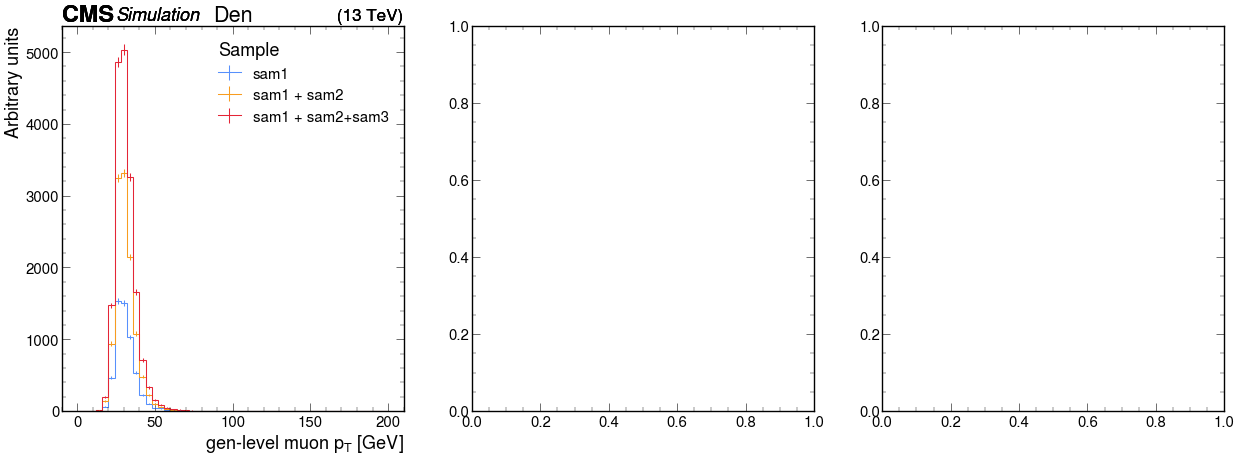

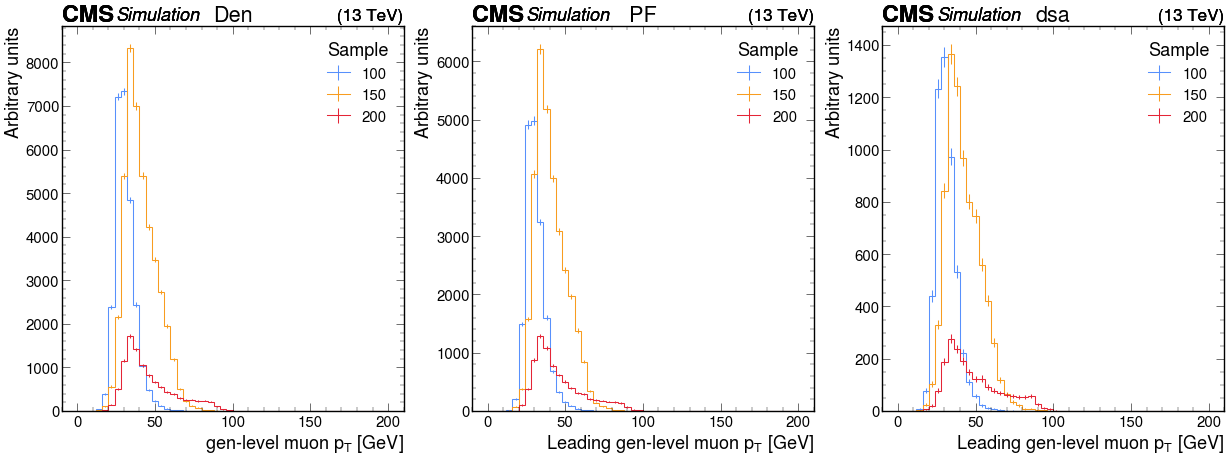

In [17]:
npl = 3
fi = "22"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]

plt.subplots(1, npl, figsize=(npl*figw, figh))
sam_mxx = ["100", "150", "200"]
plt.subplot(1, npl, 1)
# den = 0
# for sample in samples_2mu2e[0:5]:
den = out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den, label = "sam1")
# den1 = 0
# for sample in samples_2mu2e[5:10]:
den1 = out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S2]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den1, label = "sam1 + sam2")
# den2 = 0
# for sample in samples_2mu2e[10:15]:
den2 =  out[S1]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S2]["hists"]["den_genMu0_pt"][ch2, ::2j] + out[S3]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den2, label = "sam1 + sam2+sam3")
plt.title("Den")
plt.ylabel("Arbitrary units")
plt.legend(title="Sample", alignment="left", loc=0)






npl = 3
fi = "22"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]

plt.subplots(1, npl, figsize=(npl*figw, figh))
sam_mxx = ["100", "150", "200"]

# nsize = 5
# for i in range(0, len(samples_2mu2e), 5):
#     print(samples_2mu2e[i:i + nsize])
    

plt.subplot(1, npl, 1)
den = 0
for sample in samples_2mu2e[0:5]:
    den = den + out[sample]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den, label = "100")
den1 = 0
for sample in samples_2mu2e[5:10]:
    den1 = den1 + out[sample]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den1, label = "150")
den2 = 0
for sample in samples_2mu2e[10:15]:
    den2 = den2 + out[sample]["hists"]["den_genMu0_pt"][ch2, ::2j]
utilities.plot(den2, label = "200")
plt.title("Den")
plt.ylabel("Arbitrary units")
plt.legend(title="Sample", alignment="left", loc=0)
###################################
plt.subplot(1, npl, 2)
den = 0
for sample in samples_2mu2e[0:5]:
    den = den + out[sample]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]
utilities.plot(den, label = "100")
den1 = 0
for sample in samples_2mu2e[5:10]:
    den1 = den1 + out[sample]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]
utilities.plot(den1, label = "150")
den2 = 0
for sample in samples_2mu2e[10:15]:
    den2 = den2 + out[sample]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]
utilities.plot(den2, label = "200")
plt.title("PF")
plt.ylabel("Arbitrary units")
plt.legend(title="Sample", alignment="left", loc=0)
#####################################
plt.subplot(1, npl, 3)
den = 0
for sample in samples_2mu2e[0:5]:
    den = den + out[sample]["hists"]["num_genMu0_pt_dsa"][ch2, ::2j]
utilities.plot(den, label = "100")
den1 = 0
for sample in samples_2mu2e[5:10]:
    den1 = den1 + out[sample]["hists"]["num_genMu0_pt_dsa"][ch2, ::2j]
utilities.plot(den1, label = "150")
den2 = 0
for sample in samples_2mu2e[10:15]:
    den2 = den2 + out[sample]["hists"]["num_genMu0_pt_dsa"][ch2, ::2j]
utilities.plot(den2, label = "200")
plt.title("dsa")
plt.ylabel("Arbitrary units")
plt.legend(title="Sample", alignment="left", loc=0)

## Efficiency for PF and DSA muons for Mxx = 100 GeV

/home/cms-jovyan/SIDM/sidm/tools/utilities.py:152: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:147: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:153: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


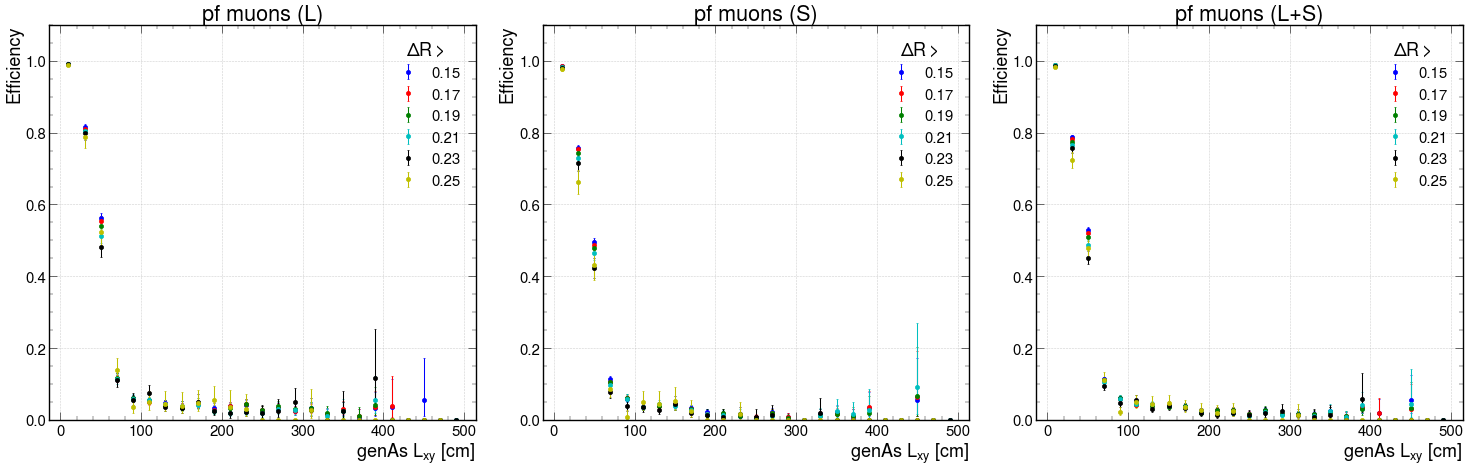

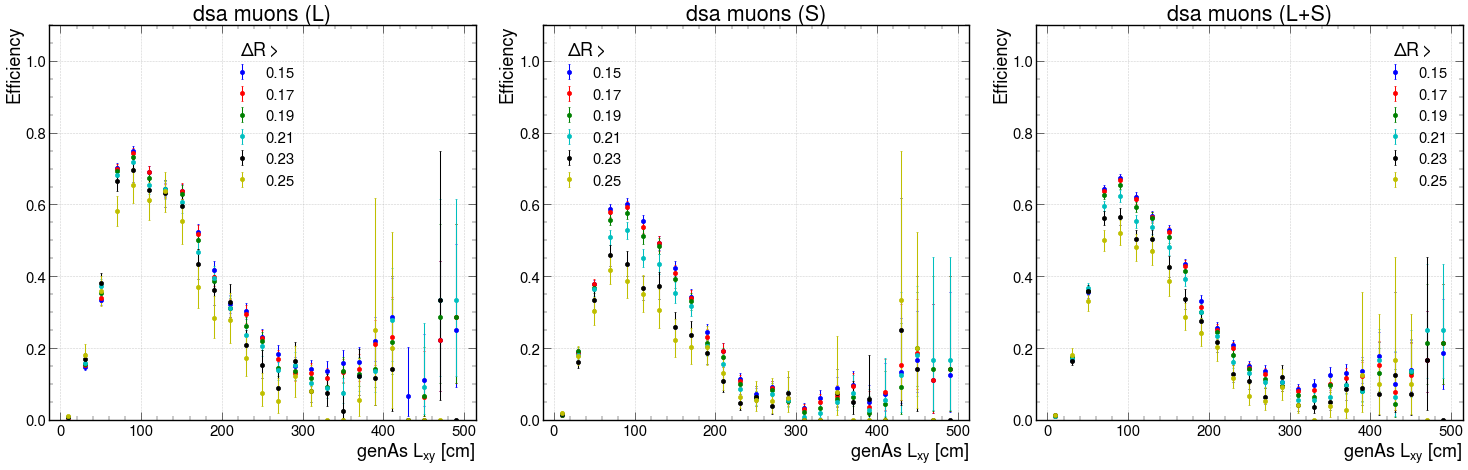

In [4]:
#pf dsa muons at mxx=100
for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[2].set_ylabel("Efficiency")
    ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[2].set_title(f"{mu} muons (L+S)")
    ax[2].set_ylim(0, 1.10)
    ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    ax[2].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/eff_28_{mu}_genA_lxy_m100.png", bbox_inches="tight")


## Combining PF and DSA muons for Mxx = 100 GeV

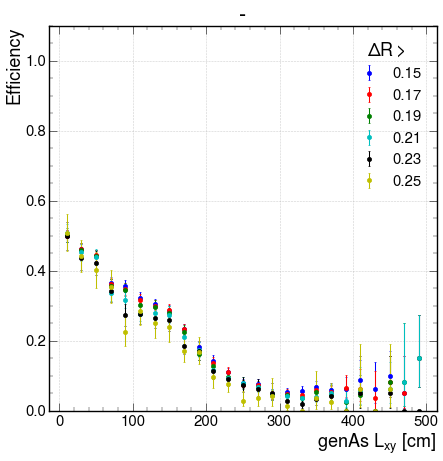

In [5]:
# sss = S5
plt.subplots(figsize=(figw, figh))
for fi, cl, lbl in zip(vr2, cols, labels):
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]

    for sss in allSamples[0:5]:
        num, den = 0, 0
        num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]
        den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    plt.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

    plt.ylabel("Efficiency")
    plt.xlabel("genAs $L_{xy}$ [cm]")
    plt.title("-")
    plt.ylim(0, 1.1)
    plt.legend(title=r"$\Delta R >$ ", loc=0)
    plt.grid(True, linestyle="--", alpha=0.6)
    # plt.savefig(f"plots/eff_28_all_genA_lxy_m100.png", bbox_inches="tight")

## Efficiency for different Bs and 3 $\Delta R$ combination

0
1
2


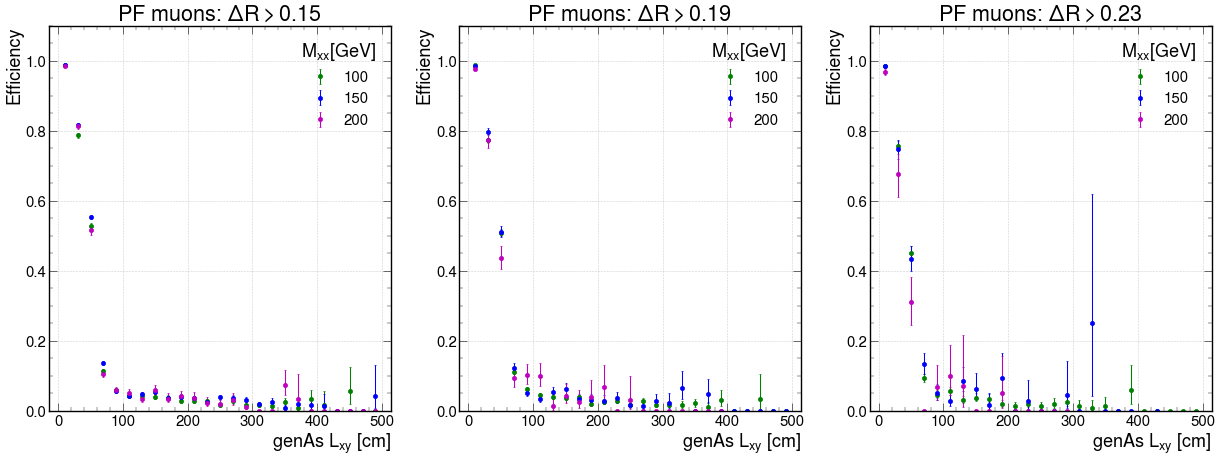

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))

drfiles = ["22", "24", "26"]
drval = ["0.15", "0.19", "0.23"]
for x, fi in enumerate(drfiles):
    print(x)
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]
    
    num, den = 0, 0
    for sss in allSamples[:5]:
        num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[x].errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="100", capsize=2)
    
    num1, den1 = 0, 0
    for sss in allSamples[5:10]:
        num1 = num1 + out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den1 = den1 + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff1, errors = utilities.get_eff_hist(num1, den1)
    centers = num1.axes[0].centers
    ax[x].errorbar(centers, eff1, yerr=errors, fmt="o", color="b", label="150", capsize=2)
    
    num2, den2 = 0, 0
    for sss in allSamples[10:15]:
        num2 = num2 + out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den2 = den2 + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff2, errors = utilities.get_eff_hist(num2, den2)
    centers = num2.axes[0].centers
    ax[x].errorbar(centers, eff2, yerr=errors, fmt="o", color="m", label="200", capsize=2)
    
    ax[x].set_ylabel("Efficiency")
    ax[x].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[x].set_title(rf"PF muons: $\Delta R > {drval[x]}$ ")
    ax[x].set_ylim(0, 1.10)
    ax[x].legend(title=r"$M_{xx} [GeV]$", loc=0)
    ax[x].grid(True, linestyle="--", alpha=0.6)

## Efficiency for PF and DSA muons for Mxx = 150 GeV

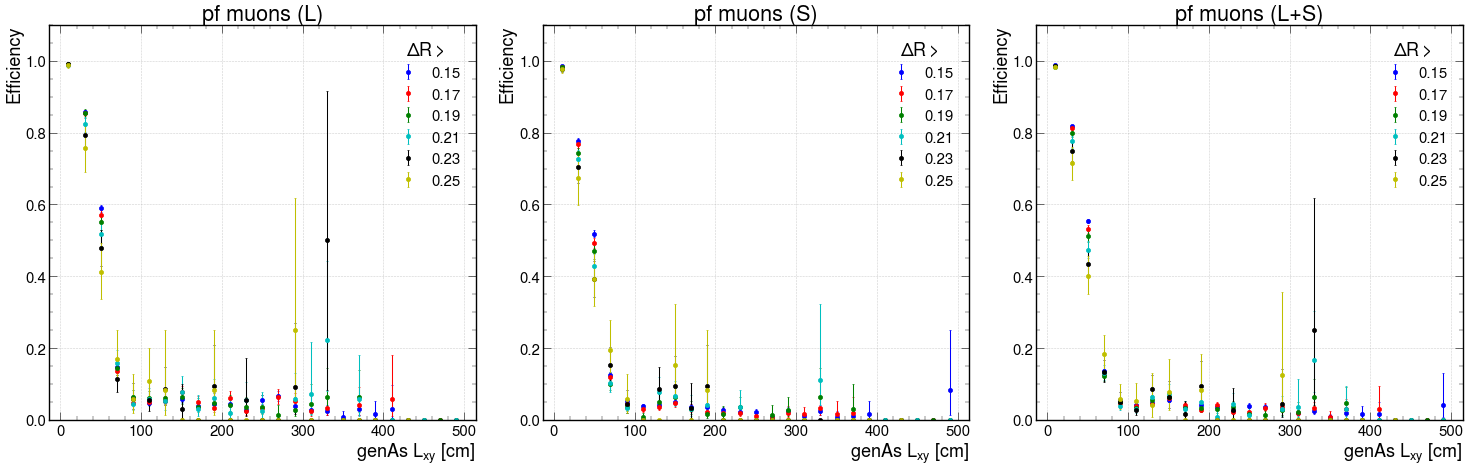

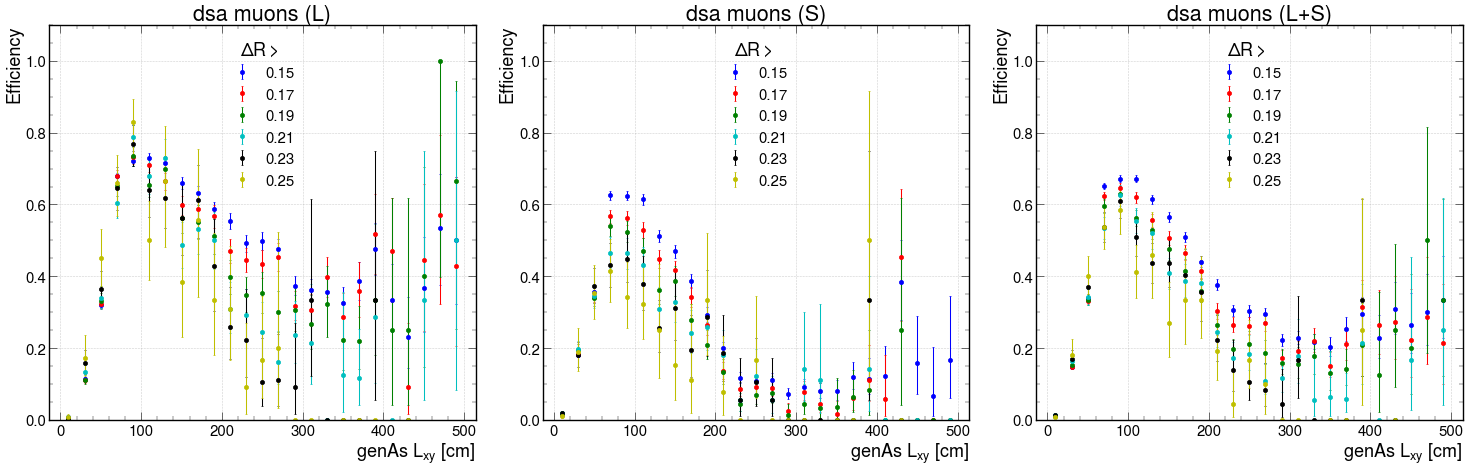

In [7]:
#pf dsa muons at mxx=150
for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[5:10]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[5:10]:
            num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[5:10]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[2].set_ylabel("Efficiency")
    ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[2].set_title(f"{mu} muons (L+S)")
    ax[2].set_ylim(0, 1.10)
    ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    ax[2].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/eff_28_{mu}_genA_lxy_m150.png", bbox_inches="tight")


## Efficiency for PF and DSA muons for Mxx = 200 GeV

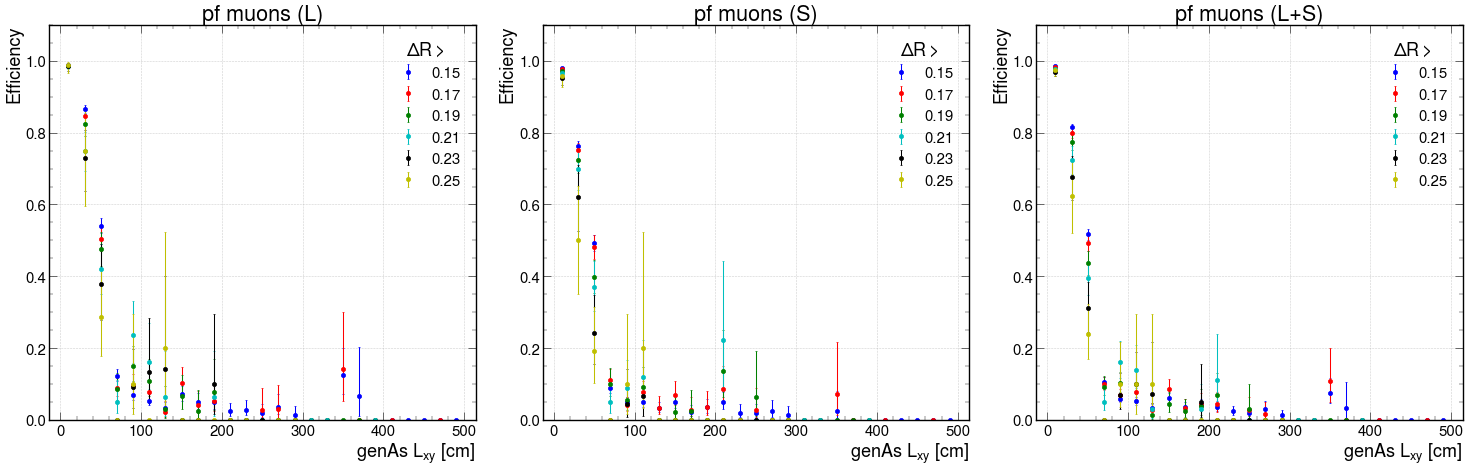

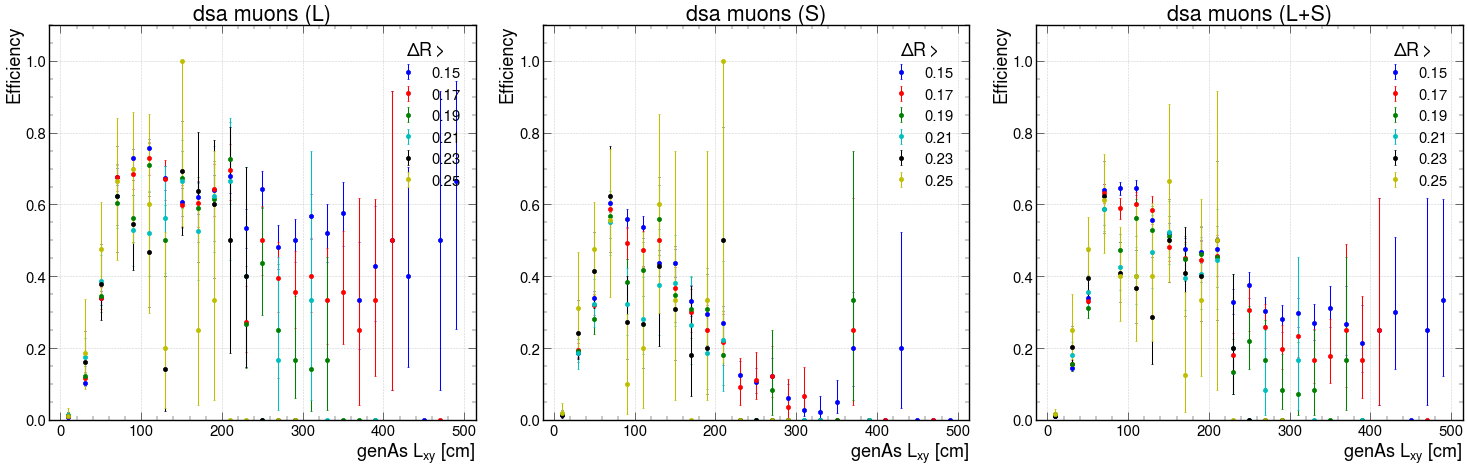

In [8]:
#pf dsa muons at mxx=200
for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[10:15]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[10:15]:
            num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)
    
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[10:15]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
            
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[2].set_ylabel("Efficiency")
    ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[2].set_title(f"{mu} muons (L+S)")
    ax[2].set_ylim(0, 1.10)
    ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    ax[2].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/eff_28_{mu}_genA_lxy_m200.png", bbox_inches="tight")


## Efficiency for PF and DSA muons for Mxx = 500 GeV

In [9]:
#pf dsa muons at mxx=500
# for mu in ["pf", "dsa"]:
#     fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
#     for fi, cl, lbl in zip(vr2, cols, labels):    
#         output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
#         out = output["out"]
        
#         num, den = 0, 0
#         for sss in allSamples[15:19]:
#             num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
#             den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
#         eff, errors = utilities.get_eff_hist(num, den)
#         centers = num.axes[0].centers
#         ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
#     ax[0].set_ylabel("Efficiency")
#     ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
#     ax[0].set_title(f"{mu} muons (L)")
#     ax[0].set_ylim(0, 1.10)
#     ax[0].legend(title=r"$\Delta R >$ ", loc=0)
#     ax[0].grid(True, linestyle="--", alpha=0.6)
    
    # for fi, cl, lbl in zip(vr2, cols, labels):    
    #     output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    #     out = output["out"]

    #     num, den = 0, 0
    #     for sss in allSamples[15:19]:
    #         num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
    #         den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
    #     eff, errors = utilities.get_eff_hist(num, den)
    #     centers = num.axes[0].centers
    #     ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    # ax[1].set_ylabel("Efficiency")
    # ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    # ax[1].set_title(f"{mu} muons (S)")
    # ax[1].set_ylim(0, 1.10)
    # ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    # ax[1].grid(True, linestyle="--", alpha=0.6)
    
    # for fi, cl, lbl in zip(vr2, cols, labels):    
    #     output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    #     out = output["out"]

    #     num, den = 0, 0
    #     for sss in allSamples[15:19]:
    #         num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
    #         den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
            
    #     eff, errors = utilities.get_eff_hist(num, den)
    #     centers = num.axes[0].centers
    #     ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    # ax[2].set_ylabel("Efficiency")
    # ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    # ax[2].set_title(f"{mu} muons (L+S)")
    # ax[2].set_ylim(0, 1.10)
    # ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    # ax[2].grid(True, linestyle="--", alpha=0.6)
    # plt.tight_layout()
    # plt.savefig(f"plots/eff_28_{mu}_genA_lxy_m500.png", bbox_inches="tight")


## Efficiency as a function of genMu pt 

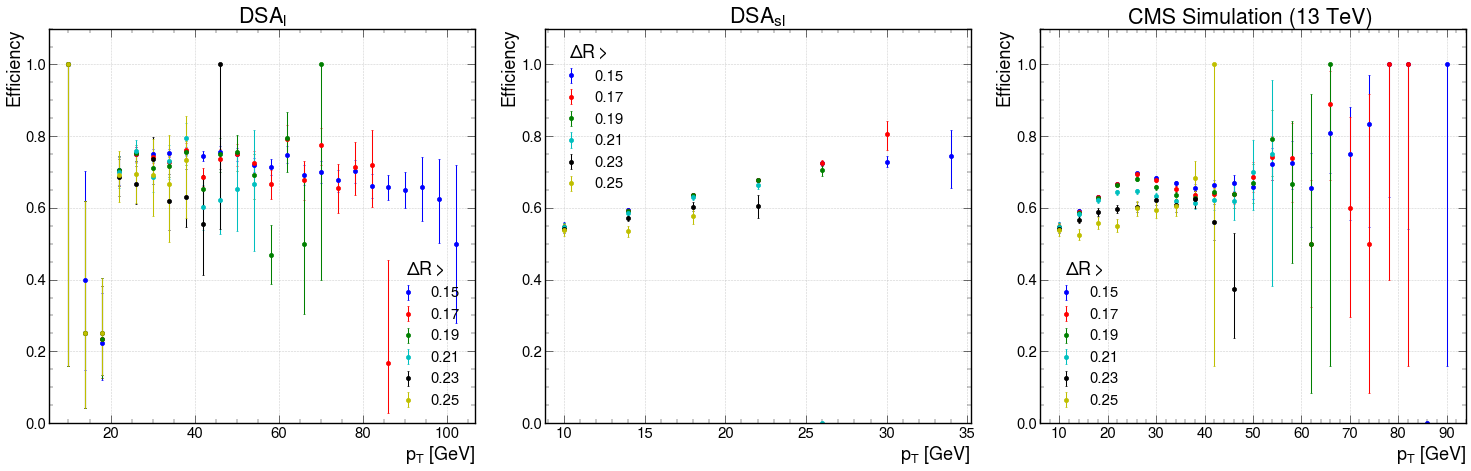

In [10]:
#pf and dsa muons genMu0 Pt

fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
for fi, cl, lbl in zip(vr2, cols, labels):    
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]

    num, den = 0, 0
    for sss in allSamples[10:15]:
        num = num + out[sss]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]
        den = den + out[sss]["hists"]["den_genMu0_pt"][ch2, ::2j]
    
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

ax[0].set_ylabel("Efficiency")
ax[0].set_xlabel(r"$p_{T}$ [GeV]")
ax[0].set_title(r"$DSA_{l}$")
ax[0].set_ylim(0, 1.10)
ax[0].legend(title=r"$\Delta R >$ ", loc=0)
ax[0].grid(True, linestyle="--", alpha=0.6)

for fi, cl, lbl in zip(vr2, cols, labels):    
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]

    num, den = 0, 0
    for sss in allSamples[:5]:
        num = num + out[sss]["hists"]["num_genMu1_pt_pf"][ch2, ::2j]
        den = den + out[sss]["hists"]["den_genMu1_pt"][ch2, ::2j]
    
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

ax[1].set_ylabel("Efficiency")
ax[1].set_xlabel(r"$p_{T}$ [GeV]")
# ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
ax[1].set_title("$DSA_{sl}$")
ax[1].set_ylim(0, 1.10)
ax[1].legend(title=r"$\Delta R >$ ", loc=0)
ax[1].grid(True, linestyle="--", alpha=0.6)

for fi, cl, lbl in zip(vr2, cols, labels):    
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]

    num, den = 0, 0
    for sss in allSamples[:5]:
        num = num + out[sss]["hists"]["num_genMu0_pt_pf"][ch2, ::2j] + out[sss]["hists"]["num_genMu1_pt_pf"][ch2, ::2j]
        den = den + out[sss]["hists"]["den_genMu0_pt"][ch2, ::2j]    + out[sss]["hists"]["den_genMu1_pt"][ch2, ::2j]

    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

ax[2].set_ylabel("Efficiency")
ax[2].set_xlabel(r"$p_{T}$ [GeV]")
ax[2].set_title(r"CMS Simulation (13 TeV) ")
ax[2].set_ylim(0, 1.10)
ax[2].legend(title=r"$\Delta R >$ ", loc=0)
ax[2].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()


In [11]:
# "den_genMu0_ptlxy"
# "den_genMu1_ptlxy"
# "num_genMu0_ptlxy_pf"
# "num_genMu1_ptlxy_pf"
# "num_genMu0_ptlxy_dsa"
# "num_genMu1_ptlxy_dsa"

## 2D- Histograms for leading muons: all(left), PF(middle), and DSA(right)

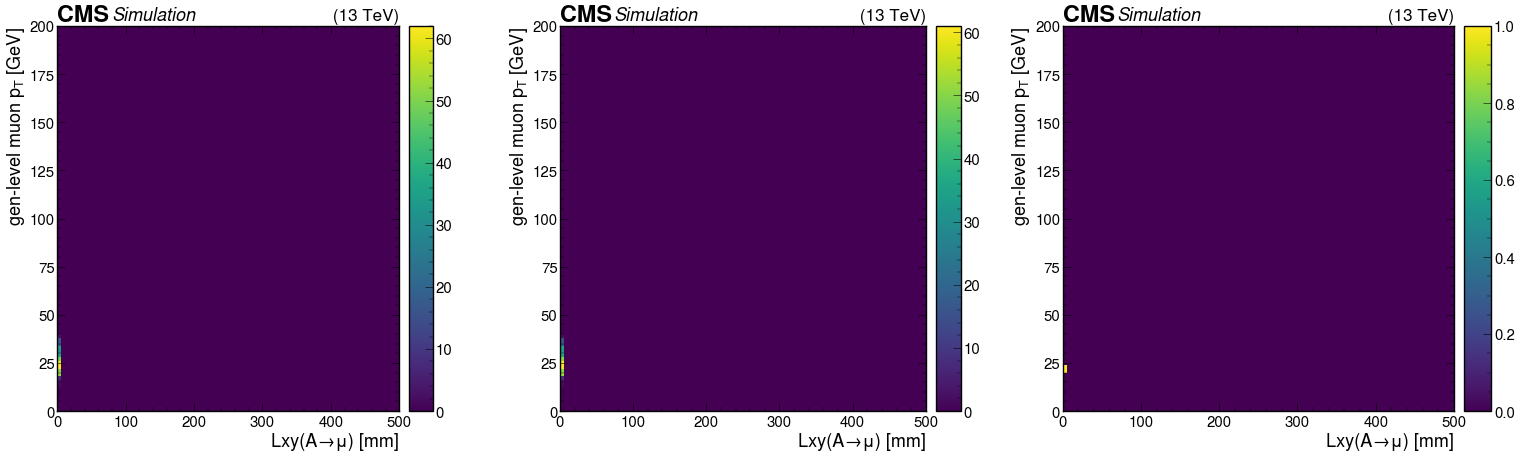

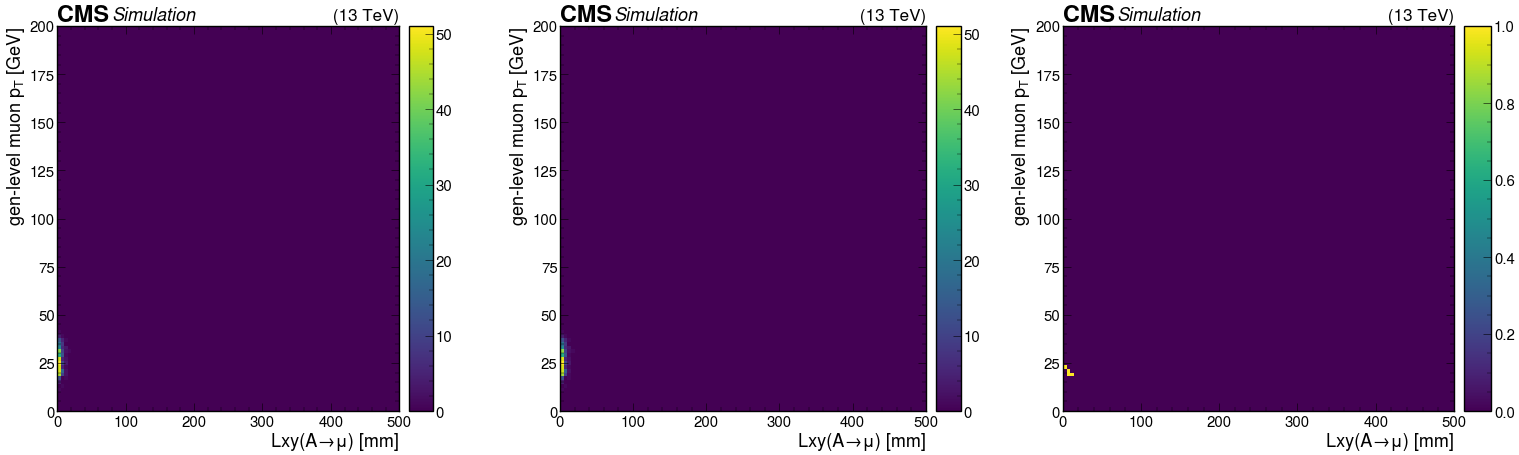

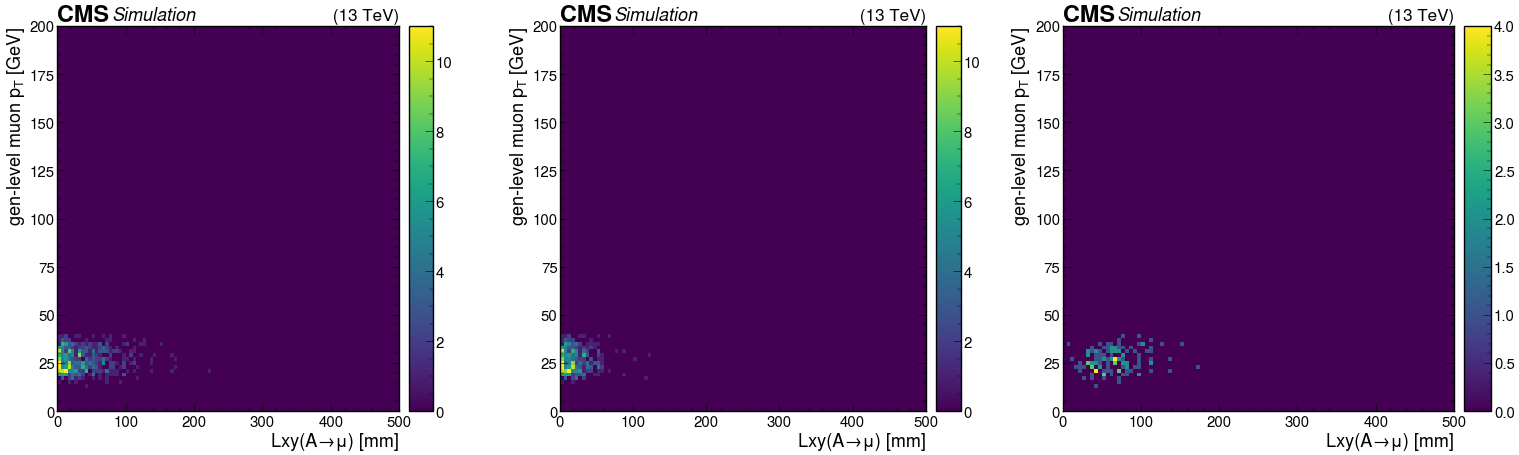

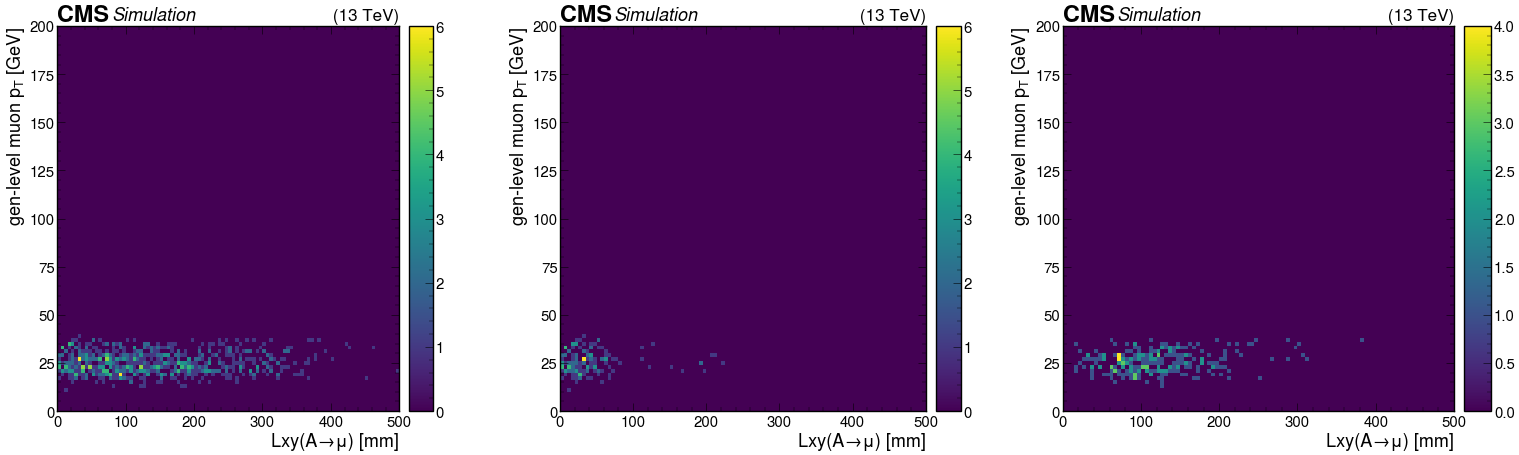

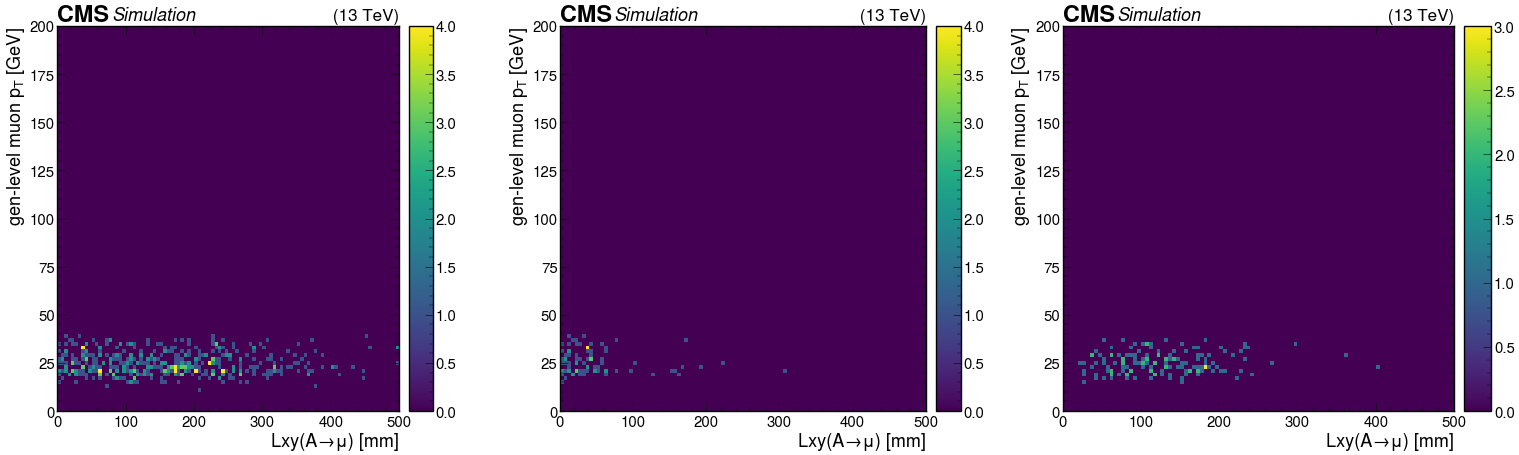

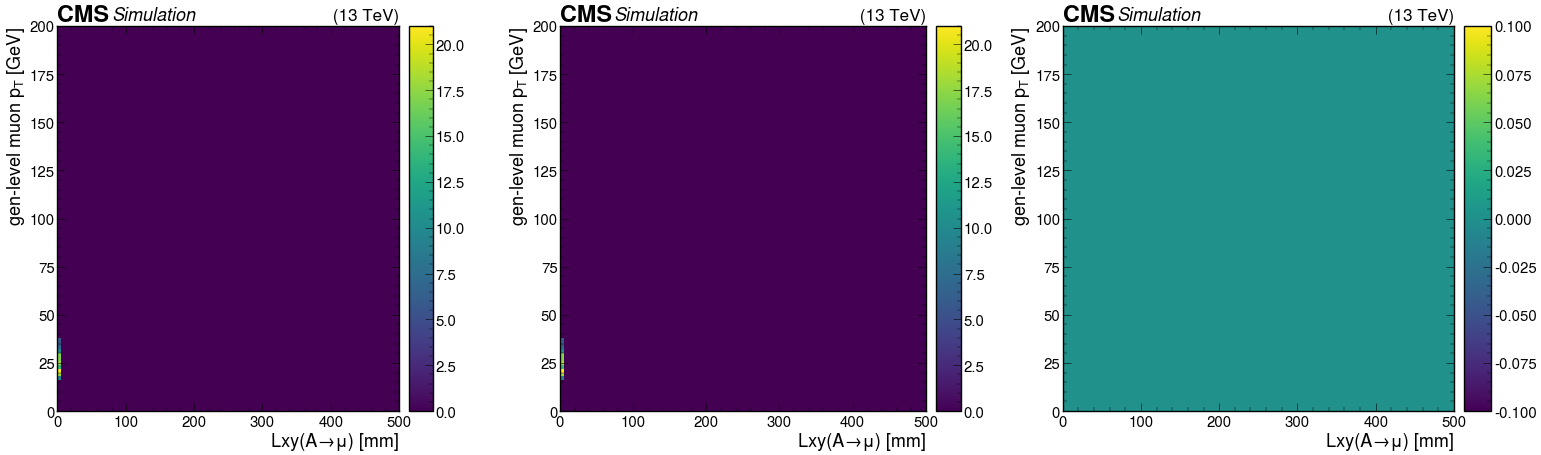

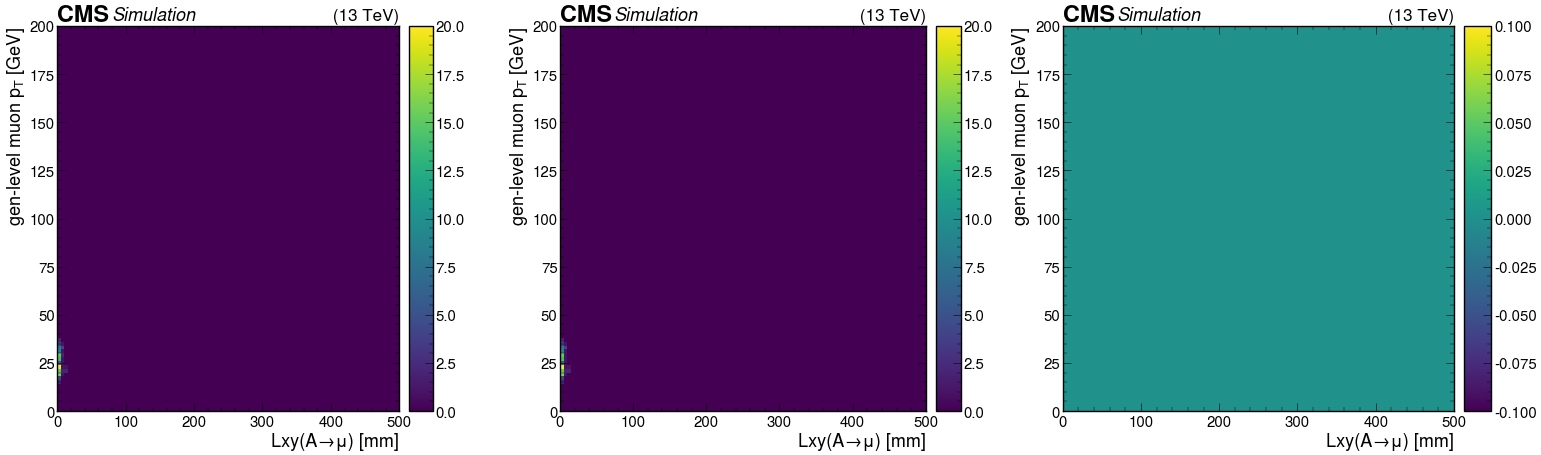

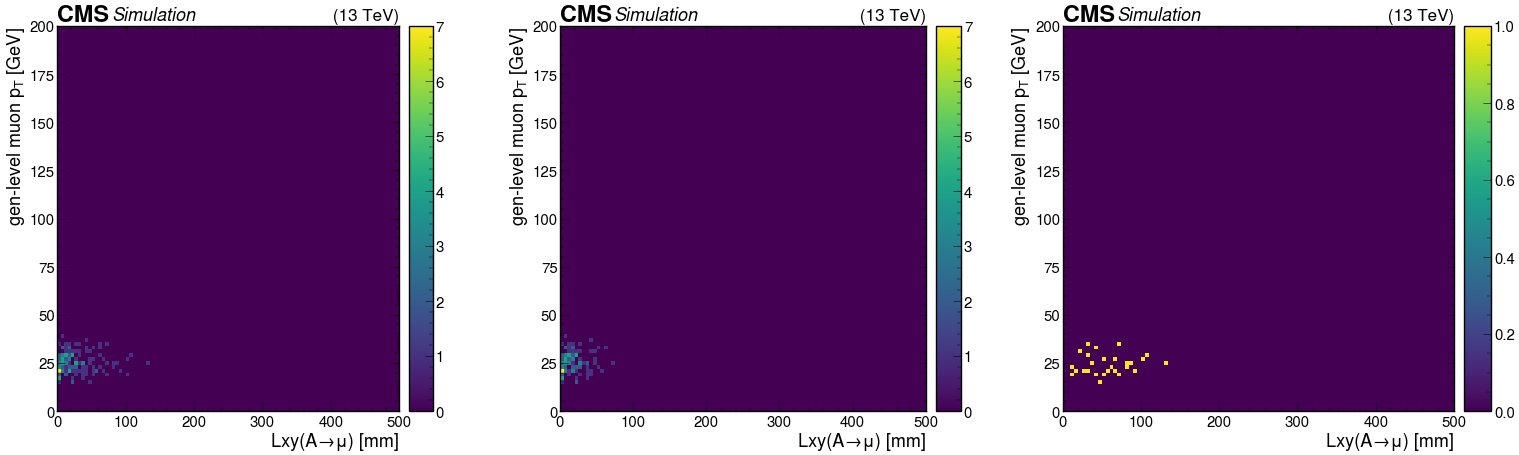

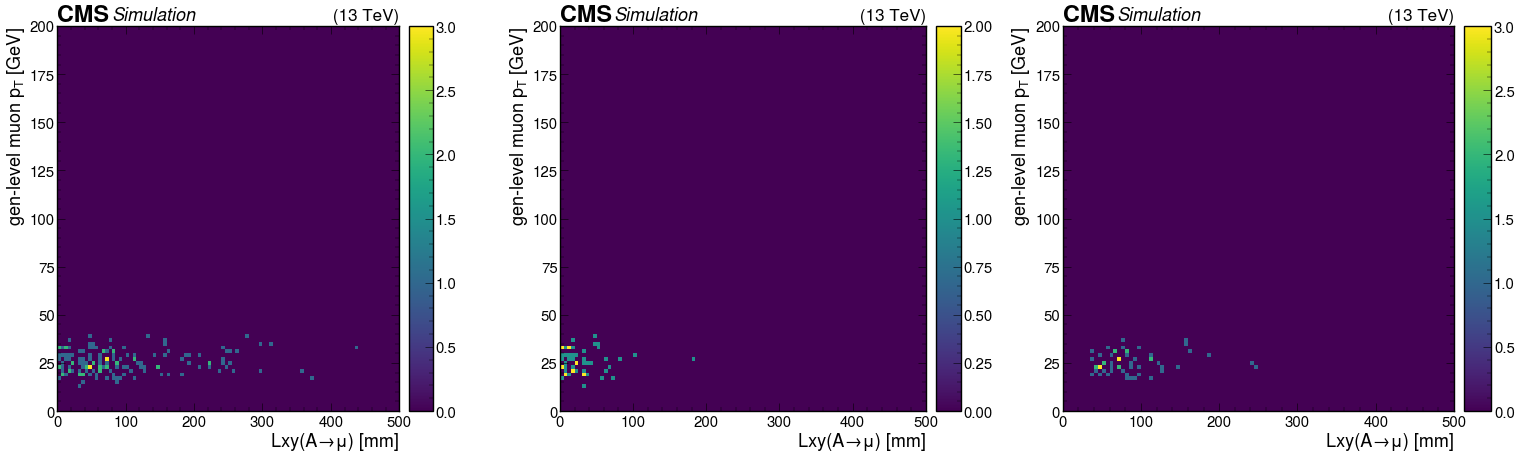

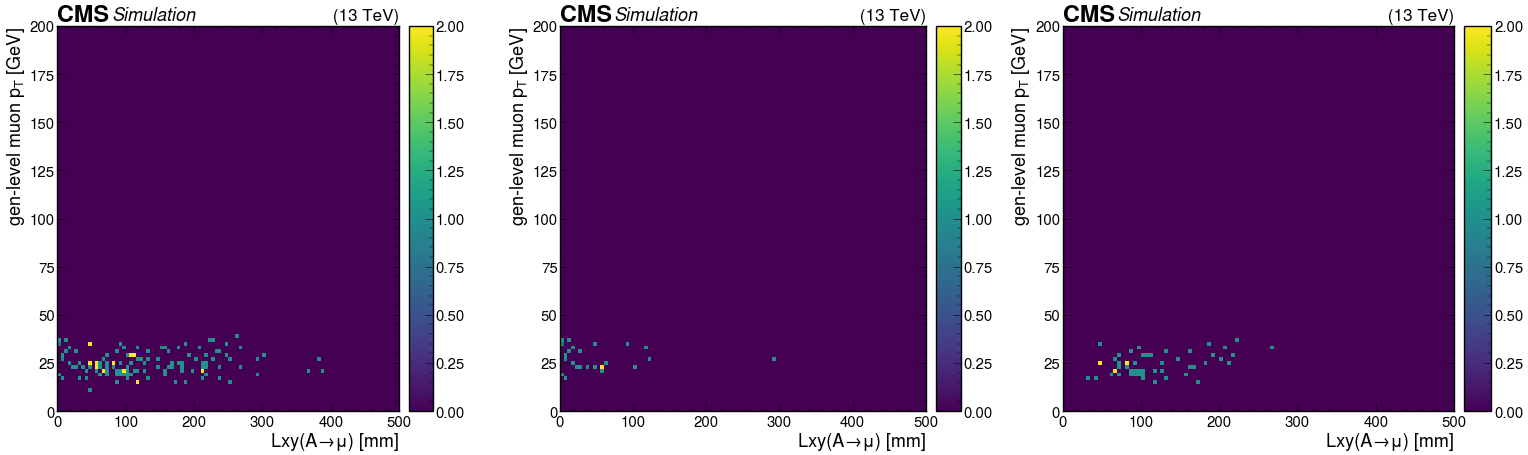

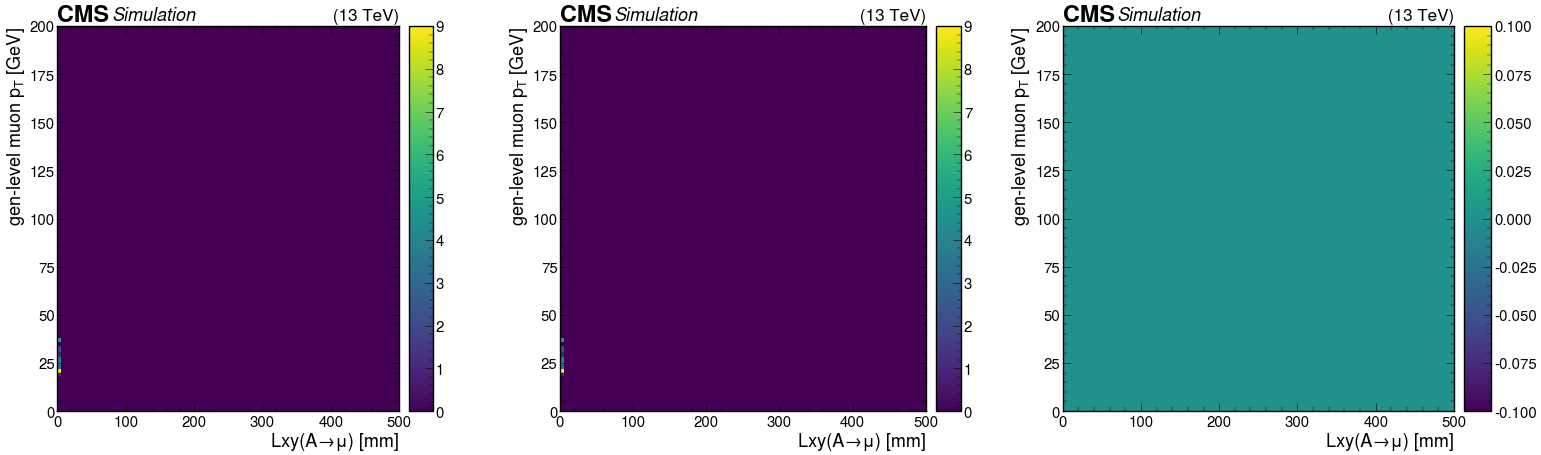

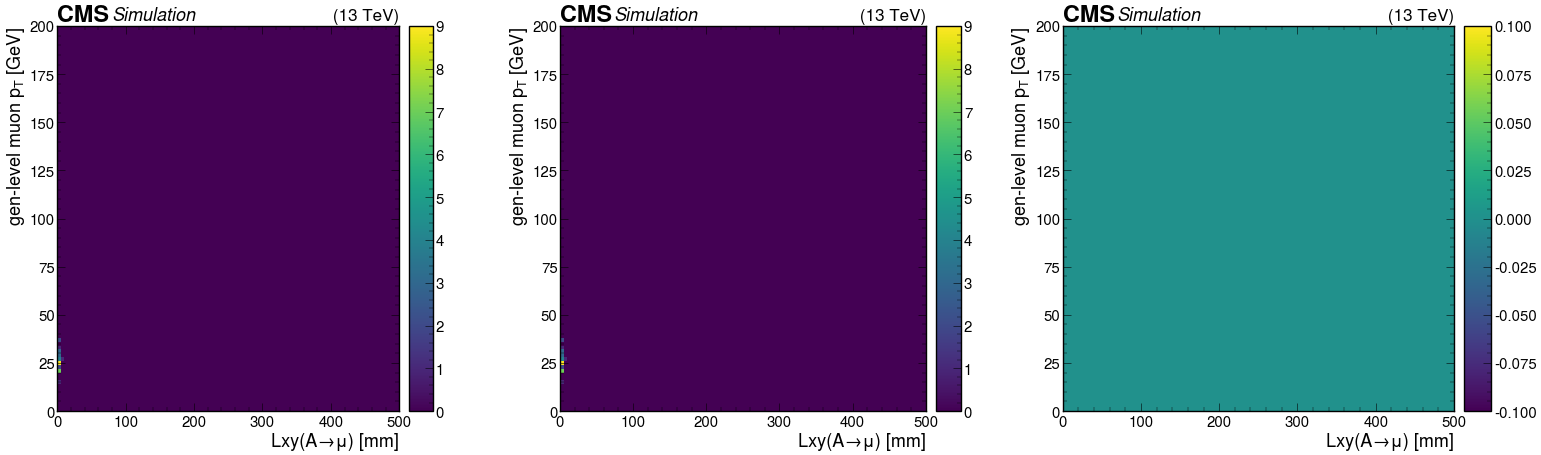

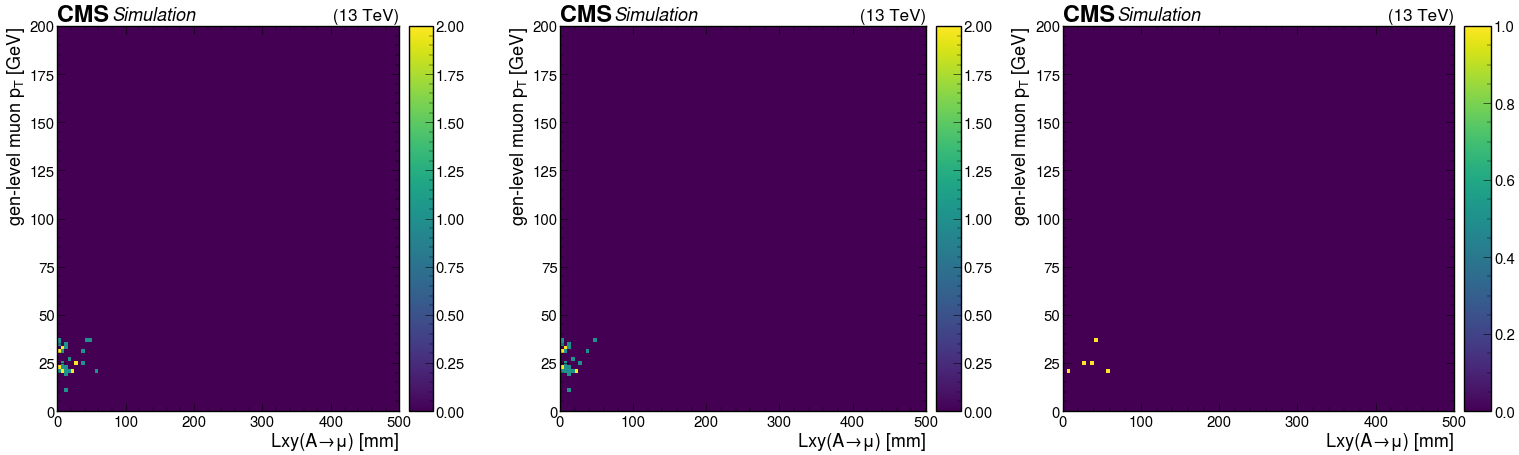

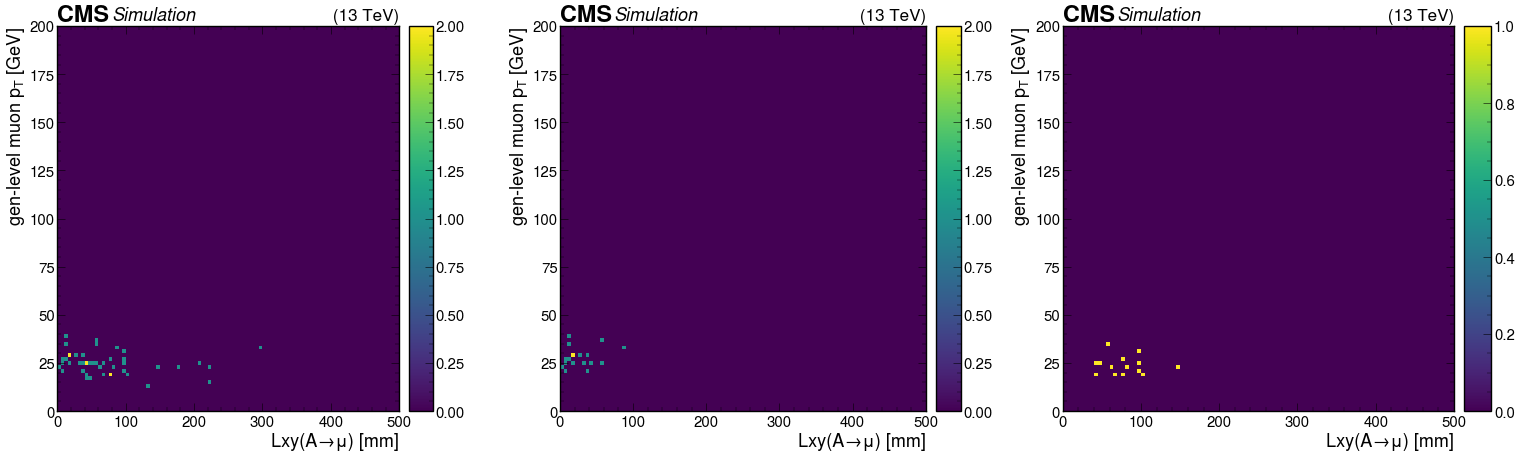

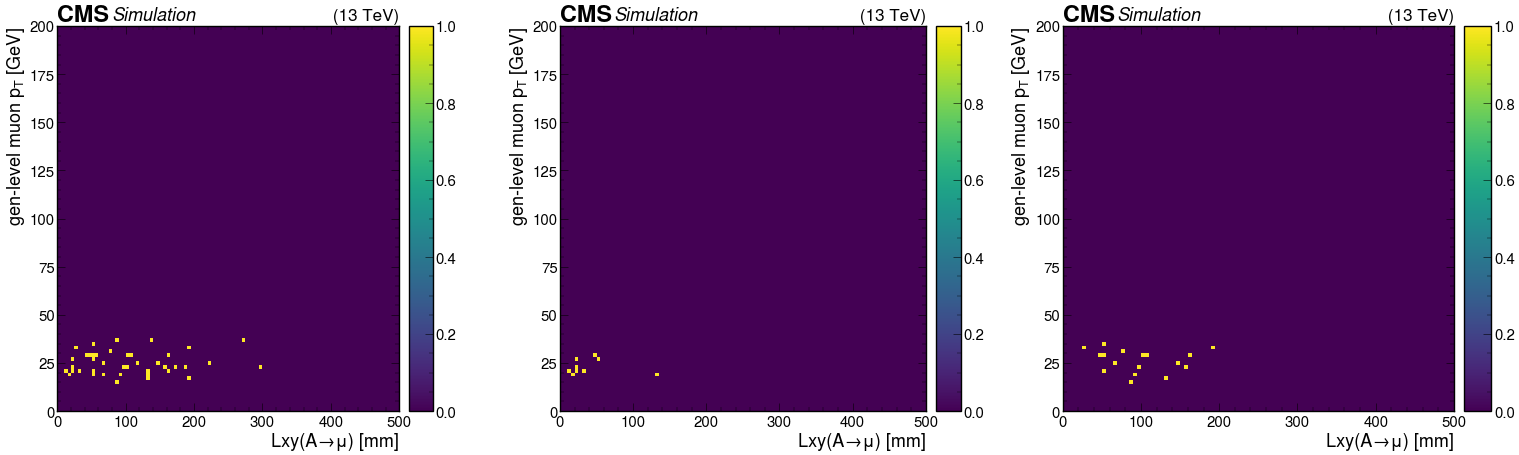

In [12]:
for sss in allSamples[:15]:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    utilities.plot(out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:])
    
    plt.subplot(1, npl, 2)
    utilities.plot(out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:])
    
    plt.subplot(1, npl, 3)
    utilities.plot(out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:])


## 2D- efficiency for a single sample.... Not working

In [13]:
# fig, ax = plt.subplots(1, 1, figsize=(figw, figh))
# sss = S5
# fi = "23"
# output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
# out = output["out"]
# num = out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
# den = out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]

# result = utilities.get_eff_hist(num, den)
# print("Type:", type(result))
# print("Length:", len(result))
# print("Contents:", result)


# eff, errors = utilities.get_eff_hist(num, den)[1]
# centers = num.axes[0].centers
# ax.errorbar(centers, eff, yerr=errors, fmt="o", color="b", label="pf", capsize=2)
# ax.set_ylabel("Efficiency")
# ax.set_xlabel(r"$p_{T}$ [GeV]")
# ax.set_title(r"CMS Simulation (13 TeV) ")
# ax.set_ylim(0, 1.10)
# ax.legend(title=r"$\Delta R >$ ", loc=0)
# ax.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()

## Histograms for gen muon pT slicing on Lxy, Starting with: (0-20), (100-120), and (150-170) cm for $\Delta R > 0.25$ and $M_{xx}=100$

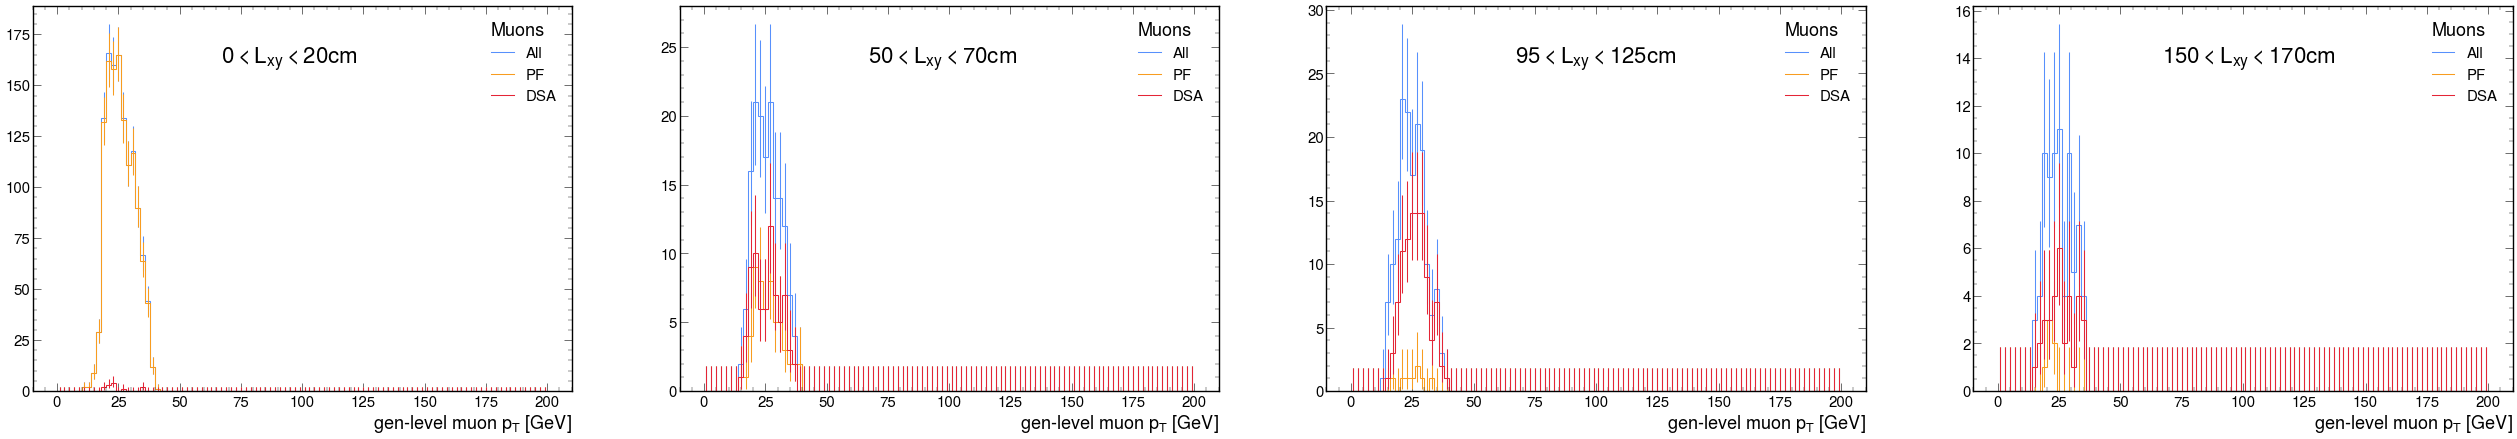

In [22]:
npl = 4
fig, ax = plt.subplots(1, npl, figsize=(npl*16, 10))
forlbl = ["All", "PF", "DSA" ]

fi = "27"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]

plt.subplot(1, npl, 1)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[0j:20j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[0j:20j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[0j:20j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[0].text(0.35, 0.85, r"$0< L_{xy} < 20 cm$", transform=ax[0].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)


plt.subplot(1, npl, 2)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[50j:70j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[50j:70j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[50j:70j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[1].text(0.35, 0.85, r"$50< L_{xy} < 70 cm$", transform=ax[1].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)

plt.subplot(1, npl, 3)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[95j:125j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[95j:125j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[95j:125j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[2].text(0.35, 0.85, r"$95< L_{xy} < 125 cm$", transform=ax[2].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)


plt.subplot(1, npl, 4)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[150j:170j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[150j:170j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[150j:170j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[3].text(0.35, 0.85, r"$150< L_{xy} < 170 cm$", transform=ax[3].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)


## Efficiency: Slicing on lxy

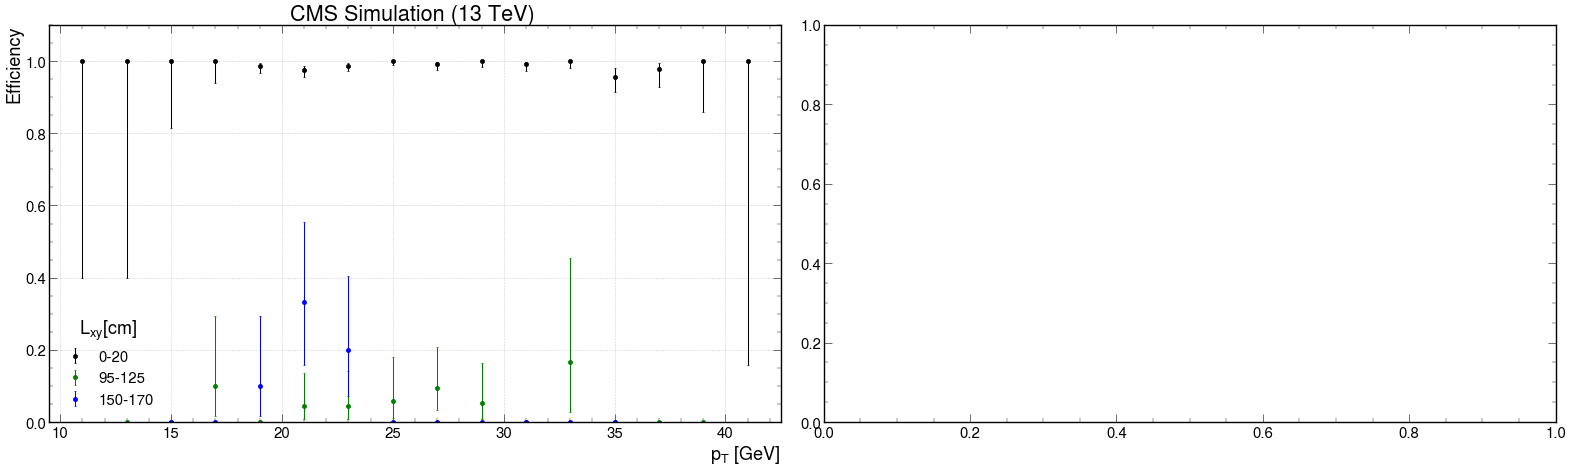

In [44]:
#pf and dsa muons genMu0 Pt
npl, fi = 2, "27" 
fig, ax = plt.subplots(1, npl, figsize=(npl*16, 10))
forlbl = ["0-20", "95-125", "150-170" ]

output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]


num_pf, num_dsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    num_pf = num_pf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    num_dsa = num_dsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den_1 = den[0j:20j:sum,:]
den_1.sum(flow=False).value
num_pf1 = num_pf[0j:20j:sum,:]
num_pf1.sum(flow=False).value
num_dsa1 = num_dsa[0j:20j:sum,:]
num_dsa1.sum(flow=False).value

den_2 = den[95j:125j:sum,:]
den_2.sum(flow=False).value
num_pf2 = num_pf[95j:125j:sum,:]
num_pf2.sum(flow=False).value
num_dsa2 = num_dsa[95j:125j:sum,:]
num_dsa2.sum(flow=False).value

den_3 = den[150j:170j:sum,:]
den_3.sum(flow=False).value
num_pf3 = num_pf[150j:170j:sum,:]
num_pf3.sum(flow=False).value
num_dsa3 = num_dsa[150j:170j:sum,:]
num_dsa3.sum(flow=False).value



plt.subplot(1, npl, 1)
effpf1, errorspf1 = utilities.get_eff_hist(num_pf1, den_1)
centers = num_pf1.axes[0].centers
ax[0].errorbar(centers, effpf1, yerr=errorspf1, fmt="o", color="k", label="0-20", capsize=2)

effpf2, errorspf2 = utilities.get_eff_hist(num_pf2, den_2)
centers = num_pf2.axes[0].centers
ax[0].errorbar(centers, effpf2, yerr=errorspf2, fmt="o", color="g", label="95-125", capsize=2)

effpf3, errorspf3 = utilities.get_eff_hist(num_pf3, den_3)
centers = num_pf3.axes[0].centers
ax[0].errorbar(centers, effpf3, yerr=errorspf3, fmt="o", color="b", label="150-170", capsize=2)

# effdsa1, errorsdsa1 = utilities.get_eff_hist(num3, den2)
# centers1 = num3.axes[0].centers
# ax[0].errorbar(centers, effpf1, yerr=errorspf1, fmt="o", color="b", label="dsa", capsize=2)
# ax[0].text(0.35, 0.85, r"$0< L_{xy} < 20 cm$", transform=ax[0].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
# plt.legend(title=r"$L_{xy}$", alignment="left", loc=0)

ax[0].set_ylabel("Efficiency")
ax[0].set_xlabel(r"$p_{T}$ [GeV]")
ax[0].set_title(r"CMS Simulation (13 TeV) ")
ax[0].set_ylim(0, 1.10)
ax[0].legend(title=r"$L_{xy} [cm]$ ", loc=0)
ax[0].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()



# plt.subplot(1, npl, 2)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[0:5]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[95j:125j:sum,:]
# den2.sum(flow=False).value
# num2 = numpf[95j:125j:sum,:]
# num2.sum(flow=False).value
# num3 = numdsa[95j:125j:sum,:]
# num3.sum(flow=False).value


# eff, errors = utilities.get_eff_hist(num2, den2)
# centers = num2.axes[0].centers
# ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
# # ax[0].text(0.35, 0.85, r"$0< L_{xy} < 20 cm$", transform=ax[0].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
# plt.legend(forlbl, title="Muons", alignment="left", loc=0)



/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


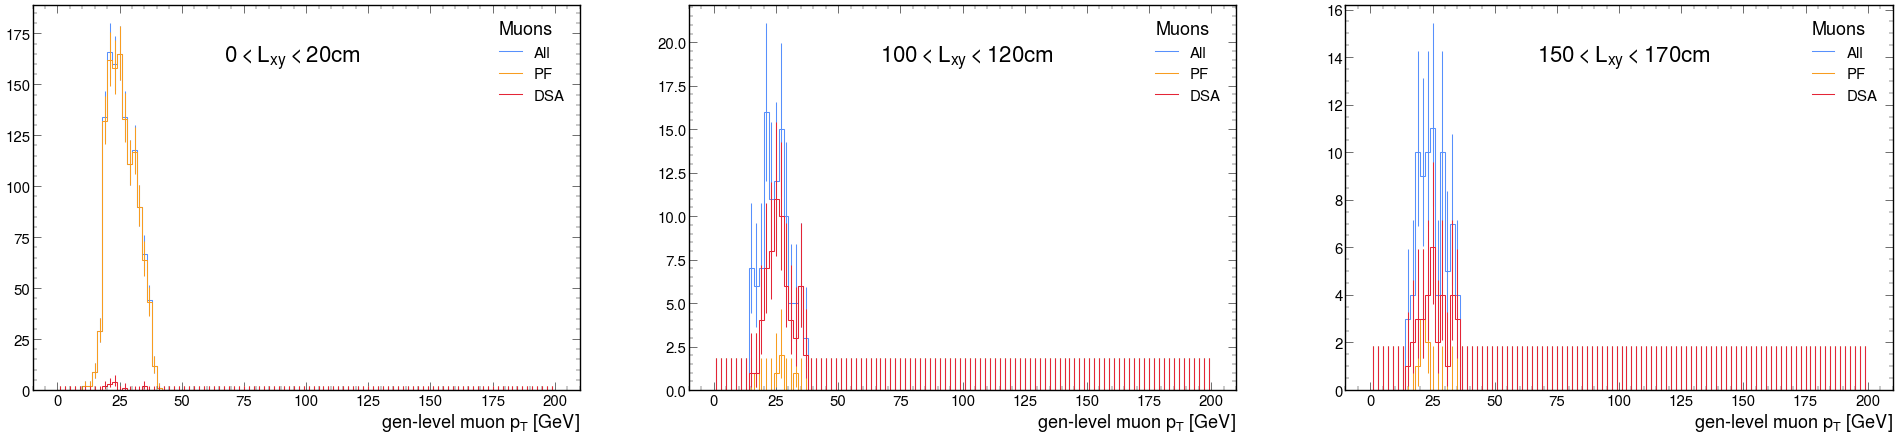

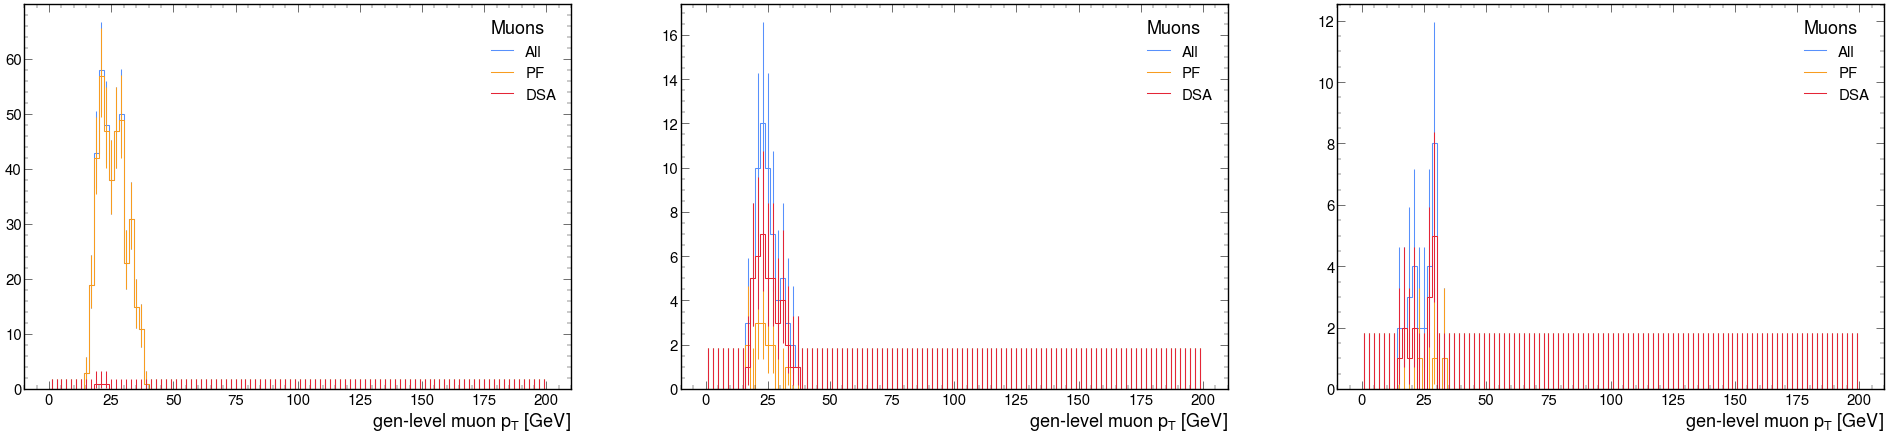

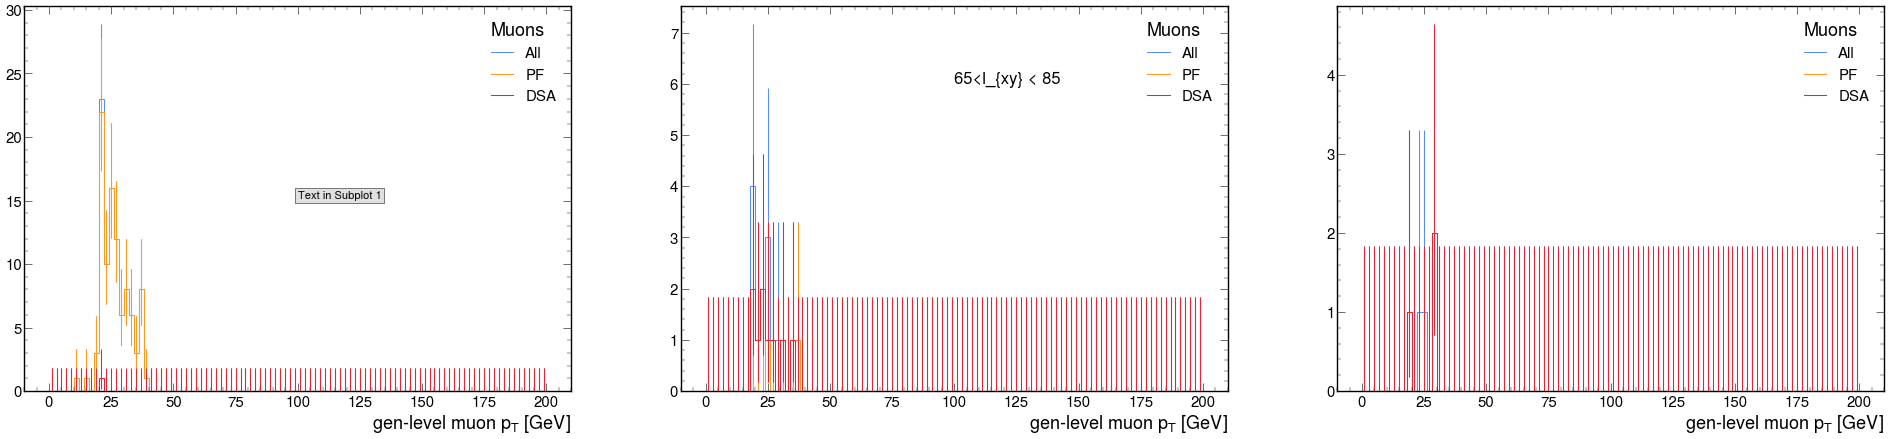

In [14]:
npl = 3
fig, ax = plt.subplots(1, npl, figsize=(npl*16, 10))
forlbl = ["All", "PF", "DSA" ]

fi = "27"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]

plt.subplot(1, npl, 1)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[0j:20j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[0j:20j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[0j:20j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[0].text(0.35, 0.85, r"$0< L_{xy} < 20 cm$", transform=ax[0].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)


plt.subplot(1, npl, 2)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[100j:120j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[100j:120j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[100j:120j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[1].text(0.35, 0.85, r"$100< L_{xy} < 120 cm$", transform=ax[1].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)


plt.subplot(1, npl, 3)
numpf, numdsa, den = 0, 0, 0
for sss in allSamples[0:5]:
    den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
    numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
    numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
den2 = den[150j:170j:sum,:]
den2.sum(flow=False).value
den2.plot1d()
num2 = numpf[150j:170j:sum,:]
num2.sum(flow=False).value
num2.plot1d()
num3 = numdsa[150j:170j:sum,:]
num3.sum(flow=False).value
num3.plot1d()
ax[2].text(0.35, 0.85, r"$150< L_{xy} < 170 cm$", transform=ax[2].transAxes, fontsize=32, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
plt.legend(forlbl, title="Muons", alignment="left", loc=0)

#######################################
####################################### mxx = 150
##########################################
# npl = 3
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[5:10]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[0j:20j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()
# # plt.legend(forlbl, title="Muons", alignment="left", loc=0)


# num2 = numpf[0j:20j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[0j:20j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()

# plt.legend(forlbl, title="Muons", alignment="left", loc=0)

# plt.subplot(1, npl, 2)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[5:10]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[55j:85j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()

# num2 = numpf[55j:85j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[55j:85j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()
# plt.legend(forlbl, title="Muons", alignment="left", loc=0)

# plt.subplot(1, npl, 3)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[5:10]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[100j:120j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()

# num2 = numpf[100j:120j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[100j:120j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()
# plt.legend(forlbl, title="Muons", alignment="left", loc=0)


# #######################################
# ####################################### mxx = 200
# ##########################################
# npl = 3
# fig, ax = plt.subplots(1, npl, figsize=(npl*16, 10))
# # forlbl = ["All", "PF", "DSA" ]

# plt.subplot(1, npl, 1)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[10:15]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[0j:20j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()
# ax[0].text(0.5, 0.5, 'Text in Subplot 1', transform=ax[0].transAxes, fontsize=16, bbox=dict(facecolor='lightgray', alpha=0.7))
# num2 = numpf[0j:20j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[0j:20j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()

# plt.legend(forlbl, title="Muons", alignment="left", loc=0)

# plt.subplot(1, npl, 2)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[10:15]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[55j:85j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()

# num2 = numpf[55j:85j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[55j:85j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()
# ax[1].text(0.5, 0.8, r"65<l_{xy} < 85", transform=ax[1].transAxes, fontsize=24, bbox=dict(facecolor='white', edgecolor="none", alpha=0.7))
# plt.legend(forlbl, title="Muons", alignment="left", loc=0)

# plt.subplot(1, npl, 3)
# numpf, numdsa, den = 0, 0, 0
# for sss in allSamples[10:15]:
#     den = den + out[sss]["hists"]["den_genMu0_ptlxy"][ch2, :,:]
#     numpf = numpf + out[sss]["hists"]["num_genMu0_ptlxy_pf"][ch2, :,:]
#     numdsa = numdsa + out[sss]["hists"]["num_genMu0_ptlxy_dsa"][ch2, :,:]
    
# den2 = den[100j:120j:sum,:]
# den2.sum(flow=False).value
# den2.plot1d()

# num2 = numpf[100j:120j:sum,:]
# num2.sum(flow=False).value
# num2.plot1d()

# num3 = numdsa[100j:120j:sum,:]
# num3.sum(flow=False).value
# num3.plot1d()
# plt.legend(forlbl, title="Muons", alignment="left", loc=0)

In [15]:
raise SystemExit("Notebook stopped intentionally after this cell.")

SystemExit: Notebook stopped intentionally after this cell.

/usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# pf muons
# sss = S6
# print()
fi = "27"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]
# print("Successfully opened: outputs/efficiency_" + fi + ".coffea")


fig, ax = plt.subplots(figsize=(figw, figh))
# num = 0
# den = 0
# for sss in samples_2mu2e:
#     num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
#     den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]

# eff, errors = utilities.get_eff_hist(num, den)
# centers = num.axes[0].centers
# ax.errorbar(centers, eff, yerr=errors, fmt="o", color="m", label="Lead", capsize=2)
# utilities.plot(num)
# utilities.plot(den)
    
num = out[S1]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[S2]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[S3]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
den = out[S1]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[S2]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[S3]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="b", label="lead pf", capsize=2)

# num_1 = out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
# den_1 = out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
# eff, errors = utilities.get_eff_hist(num_1, den_1)
# centers = num_1.axes[0].centers
# ax.errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="s-lead pf", capsize=2)

# num_t = num_0 + num_1
# den_t = den_0 + den_1
# eff, errors = utilities.get_eff_hist(num_t, den_t)
# centers = num_t.axes[0].centers
# ax.errorbar(centers, eff, yerr=errors, fmt="o", color="m", label="comb pf", capsize=2)

plt.legend(title="Muon", alignment="left", loc=0)
plt.title("PFMuon")
plt.xlabel(r"genAs $L_{xy}$ [cm]")
plt.ylabel(r"Arbitrary units")

In [ ]:
# pf muons
sss = S6
print()
fi = "27"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]
# print("Successfully opened: outputs/efficiency_" + fi + ".coffea")


fig, ax = plt.subplots(figsize=(figw, figh))
num_0 = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
den_0 = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_0, den_0)
centers = num_0.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="b", label="lead pf", capsize=2)

num_1 = out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_1 = out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_1, den_1)
centers = num_1.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="s-lead pf", capsize=2)

num_t = num_0 + num_1
den_t = den_0 + den_1
eff, errors = utilities.get_eff_hist(num_t, den_t)
centers = num_t.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="m", label="comb pf", capsize=2)

plt.legend(title="Muon", alignment="left", loc=0)
plt.title("PFMuon")
plt.xlabel(r"genAs $L_{xy}$ [cm]")
plt.ylabel("Arbitrary units")

In [ ]:
# dsa muons
sss = S6
print()
fi = "27"
output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
out = output["out"]
# print("Successfully opened: outputs/efficiency_" + fi + ".coffea")


fig, ax = plt.subplots(figsize=(figw, figh))
num_0 = out[sss]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j]
den_0 = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_0, den_0)
centers = num_0.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="b", label="lead pf", capsize=2)

num_1 = out[sss]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]
den_1 = out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_1, den_1)
centers = num_1.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="s-lead pf", capsize=2)

num_t = num_0 + num_1
den_t = den_0 + den_1
eff, errors = utilities.get_eff_hist(num_t, den_t)
centers = num_t.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="m", label="comb pf", capsize=2)

plt.legend(title="Muon", alignment="left", loc=0)
plt.title("DSA Muon")
plt.xlabel(r"genAs $L_{xy}$ [cm]")
plt.ylabel("Arbitrary units")

In [ ]:
#changing the matching
fig, ax = plt.subplots(figsize=(figw, figh))
sss = S3
# plt.subplot(1, 2, 1)
for fi, cl, lbl in zip(vr1, cols, labels):    
    output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out = output["out"]
    # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
    num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
    den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff, errors = utilities.get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("genAs $L_{xy}$ [cm]")
ax.set_title(sss)
ax.set_ylim(0, 1.10)
ax.legend(title=r"$\Delta R >$ ", loc=0)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()


fig, ax = plt.subplots(figsize=(figw, figh))
# plt.subplot(1, 2, 2)
for fi, cl, lbl in zip(vr2, cols, labels):    
    output2 = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    out2 = output2["out"]
    # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
    num_pf = out2[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out2[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
    den_tot = out2[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out2[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    eff, errors = utilities.get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("genAs $L_{xy}$ [cm]")
ax.set_title(sss)
ax.set_ylim(0, 1.10)
ax.legend(title=r"$\Delta R >$ ", loc=0)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
# sss = S5

for sss in samples_2mu2e:
    fig, ax = plt.subplots(figsize=(figw, figh))

    for fi, cl, lbl in zip(vr2, cols, labels):
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
        num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

In [ ]:
# lxy leading pf
# separation between leading and subleading and combining
# fig, ax = plt.subplots(figsize=(figw, figh))
# plt.subplot(1, npl, 1)
for sss in allSamples:
    fig, ax = plt.subplots(figsize=(figw, figh))

    for fi, cl, lbl in zip(vr2, cols, labels):
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
        num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    
# plt.subplot(1, npl, 2)
for sss in allSamples:
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
        num_pf = out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)

    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# Combined
# plt.subplot(1, npl, 3)
for sss in allSamples:
    npl = 1
    # plt.subplots(1, npl, figsize=(npl*figw, figh))
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
        # plt.subplot(1, npl, 1)
        num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
# lxy leading pf

# npl = 3
# for sss in allSamples:
# plt.subplots(1, npl, figsize=(npl*figw, figh))
# fig, ax = plt.subplots(figsize=(figw, figh))
# plt.subplot(1, 1, 1)




# fig, ax = plt.subplots(1, 2, figsize=(figw, figh))
# for sss in allSamples:
#     # plt.subplot(1, 1, 1)
#     # fig, ax = plt.subplots(1, 1, figsize=(figw, figh))
#     for fi, cl, lbl in zip(vr, cols, labels):
#         output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
#         out = output["out"]
#         # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
#         num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
#         den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
#         eff, errors = utilities.get_eff_hist(num_pf, den_tot)
#         centers = num_pf.axes[0].centers
#         ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
        
# for sss in allSamples:
#     plt.subplot(1, 1, 1)
#     for fi, cl, lbl in zip(vr, cols, labels):
#         output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
#         out = output["out"]
#         # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        
#         num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
#         den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
#         eff, errors = utilities.get_eff_hist(num_pf, den_tot)
#         centers = num_pf.axes[0].centers
#         ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)



    # for fi, cl, lbl in zip(vr, cols, labels):
    #     output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
    #     out = output["out"]
    #     # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")

    #     num_pf = out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
    #     den_tot = out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    #     eff, errors = utilities.get_eff_hist(num_pf, den_tot)
    #     centers = num_pf.axes[0].centers
    #     ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
# plt.subplot(1, npl, 3)

# ax.set_ylabel("Efficiency")
# ax.set_xlabel("genAs $L_{xy}$ [cm]")
# ax.set_title(sss)
# ax.set_ylim(0, 1.10)
# ax.legend(title=r"$\Delta R >$ ", loc=0)
# ax.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
# lxy pf
for sss in allSamples:
    npl = 1
    # plt.subplots(1, npl, figsize=(npl*figw, figh))
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):
        
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        # plt.subplot(1, npl, 1)
        num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
        
        # plt.subplot(1, npl, 2)
        # num_dsa = out[sss]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j]   + out[sss]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]
        # den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        # eff, errors = utilities.get_eff_hist(num_dsa, den_tot)
        # centers = num_dsa.axes[0].centers
        # ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
#lxy dsa
for sss in allSamples: 
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        num_pf = out[sss]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j]   + out[sss]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]
        den_tot = out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]      + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
#pt pf
for sss in allSamples: 
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        num_pf = out[sss]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]   + out[sss]["hists"]["num_genMu1_pt_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["eff_genMu0_pt"][ch2, ::2j]      + out[sss]["hists"]["eff_genMu1_pt"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel(r"genMu0 $p_{T}$ [GeV]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
#do pf
for sss in allSamples: 
    fig, ax = plt.subplots(figsize=(figw, figh))
    for fi, cl, lbl in zip(vr2, cols, labels):    
        output = coffea.util.load("outputs/efficiency_" + fi + ".coffea")
        out = output["out"]
        # print("Successfully opened: outputs/efficiency_" + fi + ".coffea")
        num_pf = out[sss]["hists"]["num_genMu0_dxy_pf"][ch2, ::2j]   + out[sss]["hists"]["num_genMu1_dxy_pf"][ch2, ::2j]
        den_tot = out[sss]["hists"]["genMu0_dxy"][ch2, ::2j]      + out[sss]["hists"]["genMu1_dxy"][ch2, ::2j]
        eff, errors = utilities.get_eff_hist(num_pf, den_tot)
        centers = num_pf.axes[0].centers
        ax.errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel(r"genMu0 $d_{0}$ [GeV]")
    ax.set_title(sss)
    ax.set_ylim(0, 1.10)
    ax.legend(title=r"$\Delta R >$ ", loc=0)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

## Plots for different gen separation $\Delta R (gen0, gen1)$ and keeping the matching fixed (0.075).

In [ ]:
# my settings

samples_2mu2e = [
    "2Mu2E_100GeV_5p0GeV_40p0mm",
    "2Mu2E_100GeV_5p0GeV_200mm",
    "2Mu2E_100GeV_5p0GeV_400mm",

#     "2Mu2E_150GeV_5p0GeV_27p0mm",
    "2Mu2E_150GeV_5p0GeV_130p0mm",
    "2Mu2E_150GeV_5p0GeV_270p0mm",

#     "2Mu2E_200GeV_5p0GeV_20p0mm",
    "2Mu2E_200GeV_5p0GeV_100p0mm",
    "2Mu2E_200GeV_5p0GeV_200p0mm",
]

allSamples = [i for i in samples_2mu2e]
print (allSamples)
S1 = samples_2mu2e[0]
S2 = samples_2mu2e[1]
S3 = samples_2mu2e[2]
S4 = samples_2mu2e[3]
S5 = samples_2mu2e[4]
S6 = samples_2mu2e[5]
S7 = samples_2mu2e[6]

channels = ["muon_eff", "dsa_eff_with_OR"]

ch1 = channels[0]
ch2 = channels[1]

legsam = [s.split("_")[1] + "  " + s.split("_")[2] + "  " + s.split("_")[3] for s in samples_2mu2e]
figw, figh = 12, 10

vr = ["16", "17", "18", "19", "20", "21"]
sss = S3
cols = ["b", "r", "g", "c", "k", "y"]
labels = ["0.15", "0.17", "0.19", "0.21", "0.23", "0.25"]

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
sss = S3

In [ ]:
fig, ax = plt.subplots(figsize=(figw, figh))

num_pf_16 = out_16[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_16[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_16 = out_16[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_16[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_16, den_tot_16)
centers = num_pf_16.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="0.15", capsize=2)


num_pf_17 = out_17[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_17[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_17 = out_17[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_17[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_17, den_tot_17)
centers = num_pf_17.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="0.17", capsize=2)

num_pf_18 = out_18[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_18[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_18 = out_18[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_18[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_18, den_tot_18)
centers = num_pf_18.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="m", label="0.19", capsize=2)

num_pf_19 = out_19[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_19[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_19 = out_19[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_19[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_19, den_tot_19)
centers = num_pf_19.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="k", label="0.21", capsize=2)

num_pf_20 = out_20[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_20[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_20 = out_20[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_20[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_20, den_tot_20)
centers = num_pf_20.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="r", label="0.23", capsize=2)

num_pf_21 = out_21[sss]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]   + out_21[sss]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
den_tot_21 = out_21[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]     + out_21[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
eff, errors = utilities.get_eff_hist(num_pf_21, den_tot_21)
centers = num_pf_21.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="c", label="0.25", capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("genAs $L_{xy}$ [cm]")
ax.set_title(sss)
ax.set_ylim(0, 1.10)
ax.legend(title=r"$\Delta R >$ ", loc=0)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# plt.savefig(f"plots/eff_{vr}_genA_lxy.png", bbox_inches="tight")

In [ ]:
# output = coffea.util.load("outputs/efficiency_08.coffea")
# print("Successfully opened file")
# coffea.util.load(your file name)

In [ ]:
# def get_eff_hist(num, den):
#     num_vals = num.values()
#     den_vals = den.values()
#     eff = np.divide(num_vals, den_vals, out=np.zeros_like(num_vals), where=den_vals > 0)
#     err = np.sqrt(eff * (1 - eff) / np.clip(den_vals, 1, None))
#     return eff, err

## Number of gen Muons and dR

In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu_n"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     plt.xlabel("Number of gen Mus")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu_genMu_dR"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_dsa_dR"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/hist_{vr}_genMus_n.png", bbox_inches="tight")

In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["den_test_pf"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["num_genMu0_pt_genAs_lxy_pf"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/hist_{vr}_genMu0_reco_dR.png", bbox_inches="tight")

In [ ]:
# "den_genMu0_pt_genAs_lxy_pf"

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

## Efficiency Definition: <br>
### $ \epsilon = \frac{\text{All Events, \#genMu>1. with dR match, ID, } }{\text{All Events, \#genMu>1}}$

# Efficiencies

## Efficiency $d_0$

In [ ]:
#do leading pf
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["genMu0_dxy"][ch2, ::2j]
    num = out[S]["hists"]["num_genMu0_dxy_pf"][ch2, ::2j]
    eff, errors = utilities.get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    # get_eff_hist(
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("$d_0$ [cm]")
ax.set_title(S1)
ax.set_ylim(0, 1.0)
ax.legend(title="Leading PF Muon", loc=0)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genMu0_d0_lpf.png", bbox_inches="tight")

In [ ]:
#do leading dsa
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["genMu0_dxy"][ch2, ::2j]
    
    num = out[S]["hists"]["num_genMu0_dxy_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    # num = out[S1]["hists"]["genMu0_dxy_num_dsa"][ch2, ::2j]
    # eff, errors = get_eff_hist(num, den)
    # centers = num.axes[0].centers
    # ax.errorbar(centers, eff, yerr=errors, fmt="o", color='g', label='dsa', capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("$d_0$ [cm]")
ax.set_title(S1)
ax.set_ylim(0, 1.1)
ax.legend(title="Leading DSA Muon", loc=0)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genMu0_d0_ldsa.png", bbox_inches="tight")

In [ ]:
# do comb both muons
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100, PF", "150, PF", "200, PF"], ["o", "s", ">"], ["b", "r", "g"]):
    den_tot = out[S]["hists"]["genMu0_dxy"][ch2, ::2j] + out[S]["hists"]["genMu1_dxy"][ch2, ::2j]
    num_pf = out[S]["hists"]["num_genMu0_dxy_pf"][ch2, ::2j] + out[S]["hists"]["num_genMu1_dxy_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)

for S, mbs, mark, col in zip(allS, ["100, DSA", "150, DSA", "200, DSA"], ["p", "*", "<"], ["c", "m", "k"]):
    den_tot = out[S]["hists"]["genMu0_dxy"][ch2, ::2j] + out[S]["hists"]["genMu1_dxy"][ch2, ::2j]
    num_dsa = out[S]["hists"]["num_genMu0_dxy_dsa"][ch2, ::2j] + out[S]["hists"]["num_genMu1_dxy_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("$d_0$ [cm]")
ax.set_title("Adding both muons")
ax.set_ylim(0, 1.1)
ax.legend(title="Bs Mass, muon", loc=0, fontsize = 24)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genMu0_d0_both.png", bbox_inches="tight")

## Dark photon lxy: leading Muon

In [ ]:
for S, mbs in zip(allS, ["100", "150", "200"]): 
    fig, ax = plt.subplots(figsize=(16, 10))
    den = out[S]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
                          
                        
    num = out[S]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='PF', capsize=2)
                          
    num = out[S]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt="^", color='g', label='DSA', capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title(S)
    ax.set_ylim(0, 1.0)
    ax.legend(title="Leading Muon")
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/eff_{vr}_genA_lxy_{mbs}.png", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
    num = out[S]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title("Leading PF Muon")
    ax.set_ylim(0, 1.10)
    ax.legend(title="Bs Mass [GeV]")
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
plt.savefig(f"plots/eff_{vr}_genA_lxy_lpf.png", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
# for clt in ["pf", "dsa"]
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    num = out[S]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title("sub Leading PF Muon")
    ax.set_ylim(0, 1.10)
    ax.legend(title="Bs Mass [GeV]")
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
plt.savefig(f"plots/eff_{vr}_genA_lxy_spf.png", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
    num = out[S]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title("Leading DSA Muon")
    ax.set_ylim(0, 1.10)
    ax.legend(title="Bs Mass [GeV]")
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
plt.savefig(f"plots/eff_{vr}_genA_lxy_ldsa.png", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
# for clt in ["pf", "dsa"]
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
    num = out[S]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    ax.set_ylabel("Efficiency")
    ax.set_xlabel("genAs $L_{xy}$ [cm]")
    ax.set_title("sub-Leading DSA Muon")
    ax.set_ylim(0, 1.10)
    ax.legend(title="Bs Mass [GeV]")
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
plt.savefig(f"plots/eff_{vr}_genA_lxy_sdsa.png", bbox_inches="tight")


Combining pf and dsa for lxy

In [ ]:
# Summing num and den for pf and dsa

fig, ax = plt.subplots(figsize=(16, 10))
den_tot = out[S1]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[S1]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
num_pf = out[S1]["hists"]["num_genAs_toMu0_lxy_pf"][ch2, ::2j] + out[S1]["hists"]["num_genAs_toMu1_lxy_pf"][ch2, ::2j]
num_dsa = out[S1]["hists"]["num_genAs_toMu0_lxy_dsa"][ch2, ::2j] + out[S1]["hists"]["num_genAs_toMu1_lxy_dsa"][ch2, ::2j]

eff, errors = get_eff_hist(num_pf, den_tot)
centers = num_pf.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="blue", label="PF", capsize=2)

eff, errors = get_eff_hist(num_dsa, den_tot)
centers = num_dsa.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color="g", label="DSA", capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("genAs $L_{xy}$ [cm]")
ax.set_title("Combining both muons: "+S1)
ax.set_ylim(0, 1.10)
ax.legend(title="Muon")
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genA_lxy.png", bbox_inches="tight")

## Muon pt

In [ ]:
#leading and subleading pf and dsa muons 

fig, ax = plt.subplots(figsize=(16, 10))
denl = out[S1]["hists"]["eff_genMu0_pt"][ch2, ::2j]
dens = out[S1]["hists"]["eff_genMu1_pt"][ch2, ::2j]

num_lpf = out[S1]["hists"]["num_genMu0_pt_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num_lpf, denl)
centers = num_lpf.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='l-PF', capsize=2)

num_spf = out[S1]["hists"]["num_genMu1_pt_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num_spf, dens)
centers = num_spf.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="s", color='r', label='s-PF', capsize=2)

num_ldsa = out[S1]["hists"]["num_genMu0_pt_dsa"][ch2, ::2j]
eff, errors = get_eff_hist(num_ldsa, denl)
centers = num_ldsa.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="^", color='g', label='l-DSA', capsize=2)

num_sdsa = out[S1]["hists"]["num_genMu1_pt_dsa"][ch2, ::2j]
eff, errors = get_eff_hist(num_sdsa, dens)
centers = num_sdsa.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt=">", color='m', label='l-DSA', capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("Leading gen-level muon $p_{T}$ [GeV]")
ax.set_title(S1)
ax.set_ylim(0, 1.1)
ax.legend(title="Muon", fontsize=24)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()
plt.savefig(f"plots/eff_{vr}_genMu_pt.png", bbox_inches="tight")

### combining leading and subleading for both pf and DSA

In [ ]:
# Summing num and den for pf and dsa
fig, ax = plt.subplots(figsize=(16, 10))

dent = denl+dens
num_pf = num_lpf + num_spf
num_dsa = num_ldsa + num_sdsa

eff, errors = get_eff_hist(num_pf, dent)
centers = num_pf.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='g', label='PF', capsize=2)

eff, errors = get_eff_hist(num_dsa, dent)
centers = num_dsa.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='DSA', capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("Gen-level muon $p_{T}$ [GeV]")
ax.set_title("Comb both muons: "+S1)
ax.set_ylim(0, 1.1)
ax.legend(title="Muon", fontsize=24)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()
plt.savefig(f"plots/eff_genMu_pt_{vr}_both.png", bbox_inches="tight")

## $\Delta R$

In [ ]:
#dr
fig, ax = plt.subplots(figsize=(16, 10))
den = out[S1]["hists"]["genMu_genMu_dR"][ch2, ::2j]

num = out[S1]["hists"]["genMu_genMu_dR_num_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='pf', capsize=2)

num = out[S1]["hists"]["genMu_genMu_dR_num_dsa"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='g', label='dsa', capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("$\Delta$ R $mu$ (g1, g2)")
ax.set_title(S1)
ax.set_ylim(0, 1.0)
ax.legend(title="Leading Muon")
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genMu0_dR.png", bbox_inches="tight")

In [ ]:
#dr
fig, ax = plt.subplots(figsize=(16, 10))
for S, mbs, mark, col in zip(allS, ["100", "150", "200"], ["o", "s", ">"], ["b", "r", "g"]):
    den = out[S]["hists"]["genMu_genMu_dR"][ch2, ::2j]
    
    num = out[S]["hists"]["genMu_genMu_dR_num_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num, den)
    centers = num.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
    # num = out[S1]["hists"]["genMu_genMu_dR_num_dsa"][ch2, ::2j]
    # eff, errors = get_eff_hist(num, den)
    # centers = num.axes[0].centers
    # ax.errorbar(centers, eff, yerr=errors, fmt="o", color='g', label='dsa', capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("$\Delta$ R $mu$ (g1, g2)")
ax.set_title(S1)
ax.set_ylim(0, 1.0)
ax.legend(title="Muon PF")
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

# plt.savefig(f"plots/eff_genMu0_dR_{vr}.png", bbox_inches="tight")

## $\eta$

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
den = out[S1]["hists"]["genMu0_eta"][ch2, ::2j]

num = out[S1]["hists"]["num_genMu0_eta_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='pf', capsize=2)

num = out[S1]["hists"]["num_genMu0_eta_dsa"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='g', label='dsa', capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("$\eta$")
ax.set_title(S1)
ax.set_ylim(0, 1.0)
ax.legend(title="Leading Muon", loc=0, fontsize=30)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

# plt.savefig(f"plots/eff_genMu0_eta_{vr}.png", bbox_inches="tight")

In [ ]:
# \eta comb both muons
fig, ax = plt.subplots(figsize=(16, 10))

for S, mbs, mark, col in zip(allS, ["100, PF", "150, PF", "200, PF"], ["o", "s", ">"], ["b", "r", "g"]):
    den_tot = out[S]["hists"]["genMu0_eta"][ch2, ::2j] + out[S]["hists"]["genMu1_eta"][ch2, ::2j]
    num_pf = out[S]["hists"]["num_genMu0_eta_pf"][ch2, ::2j] + out[S]["hists"]["num_genMu1_eta_pf"][ch2, ::2j]
    eff, errors = get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)

for S, mbs, mark, col in zip(allS, ["100, DSA", "150, DSA", "200, DSA"], ["p", "*", "<"], ["c", "m", "k"]):
    den_tot = out[S]["hists"]["genMu0_eta"][ch2, ::2j] + out[S]["hists"]["genMu1_eta"][ch2, ::2j]
    num_dsa = out[S]["hists"]["num_genMu0_eta_dsa"][ch2, ::2j] + out[S]["hists"]["num_genMu1_eta_dsa"][ch2, ::2j]
    eff, errors = get_eff_hist(num_pf, den_tot)
    centers = num_pf.axes[0].centers
    ax.errorbar(centers, eff, yerr=errors, fmt=mark, color=col, label=mbs, capsize=2)
    
ax.set_ylabel("Efficiency")
ax.set_xlabel("$eta$")
ax.set_title("Adding both muons")
ax.set_ylim(0, 1.1)
ax.legend(title="Bs Mass, muon", loc=0, fontsize = 24)
ax.grid(True, linestyle="-", alpha=0.6)
plt.tight_layout()

plt.savefig(f"plots/eff_{vr}_genMu0_eta_both.png", bbox_inches="tight")

## 2d plots

In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*10, 4))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["den_genMu0_pt_genAs_lxy_pf"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("TBD")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["tryero"][ch2, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("")
#     # plt.xlabel("")
#     plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/number_gen_mus_{vr}.png", bbox_inches="tight")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10))
den = out[S1]["hists"]["genMu0_eta"][ch2, ::2j]

num = out[S1]["hists"]["genMu0_eta_num_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='pf', capsize=2)

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

## Dark photon lxy

In [ ]:
npl = 1
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1, npl, 1)

utilities.plot(out[sample]["hists"]["genAs_toMu_lxy_eff_den"][ch2, :], density=False, label="den")
utilities.plot(out[sample]["hists"]["genAs_toMu_lxy_eff_num_pf"][ch2, :], density=False, label="num")
utilities.plot(out[sample]["hists"]["genAs_toMu_lxy_eff_num_dsa"][ch2, :], density=False, label="num")
plt.legend(muonleg, title="Events", alignment="left", loc=0)
plt.title(S1)
plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
# S1 = 
fig, ax = plt.subplots(figsize=(16, 10))
den = out[S2]["hists"]["genAs_toMu_lxy_eff_den"][ch2, ::2j]

num = out[S2]["hists"]["genAs_toMu_lxy_eff_num_pf"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="o", color='b', label='PF', capsize=2)

num = out[S2]["hists"]["genAs_toMu_lxy_eff_num_dsa"][ch2, ::2j]
eff, errors = get_eff_hist(num, den)
centers = num.axes[0].centers
ax.errorbar(centers, eff, yerr=errors, fmt="^", color='g', label='DSA', capsize=2)

ax.set_ylabel("Efficiency")
ax.set_xlabel("Leading gen-level muon $p_{T}$ [GeV]")
ax.set_title(S2)
ax.set_ylim(0, 1.0)
ax.legend(title="Muon")
ax.grid(True, linestyle="--", alpha=0.6)

## (sub)Leading Gen muon pt

In [ ]:
npl = 2
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1, npl, 1)

utilities.plot(out[S1]["hists"]["genMu0_pt"][ch2, :], density=False, label="den")
utilities.plot(out[S1]["hists"]["genMu0_pt_num_pf"][ch2, :], density=False, label="num")
utilities.plot(out[S1]["hists"]["genMu0_pt_num_dsa"][ch2, :], density=False, label="num")
plt.legend(muonleg, title="Leading Muon", alignment="left", loc=0)
plt.title(S1)
plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
utilities.plot(out[S1]["hists"]["genMu1_pt"][ch2, :], density=False, label="den")
utilities.plot(out[S1]["hists"]["genMu1_pt_num_pf"][ch2, :], density=False, label="num")
utilities.plot(out[S1]["hists"]["genMu1_pt_num_dsa"][ch2, :], density=False, label="num")
plt.legend(muonleg, title="s-Leading Muon", alignment="left", loc=0)
plt.title(S1)
plt.ylabel("Arbitrary units")

Adding subleading muon.

## $\Delta R$

In [ ]:
npl = 1
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1, npl, 1)
# forleg = ["All", "PF", "DSA", "DSA with OR"]

utilities.plot(out[S1]["hists"]["genMu_genMu_dR"][ch2, :], density=False, label="den")
utilities.plot(out[S1]["hists"]["genMu_genMu_dR_num_pf"][ch2, :], density=False, label="num")
utilities.plot(out[S1]["hists"]["genMu_genMu_dR_num_dsa"][ch2, :], density=False, label="num")
plt.legend(muonleg, title="Events", alignment="left", loc=0)
plt.title("DEN")
# plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Arbitrary units")

## $d_0$

In [ ]:
npl = 1
plt.subplots(1, npl, figsize=(npl*16, 10))

plt.subplot(1, npl, 1)
utilities.plot(out[S1]["hists"]["genMu0_dxy"][ch1, :], density=False, label="den")
utilities.plot(out[S1]["hists"]["genMu0_dxy_num_pf"][ch1, :], density=False, label="num")
utilities.plot(out[S1]["hists"]["genMu0_dxy_num_dsa"][ch2, :], density=False, label="num")
# utilities.plot(out[S1]["hists"]["genMu0_dxy_num_dsa"][ch3, :], density=False, label="num")
plt.legend(muonleg, title="Events", alignment="left", loc=0)
plt.title(S1)
# plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Arbitrary units")

## $\eta$

In [ ]:
npl = 1
plt.subplots(1, npl, figsize=(npl*16, 10))

plt.subplot(1, npl, 1)
utilities.plot(out[S1]["hists"]["genMu0_eta"][ch2, :], density=False, label="den")
utilities.plot(out[S1]["hists"]["genMu0_eta_num_pf"][ch2, :], density=False, label="num")
utilities.plot(out[S1]["hists"]["genMu0_eta_num_dsa"][ch2, :], density=False, label="num")
# utilities.plot(out[S1]["hists"]["genMu0_eta_num_dsa"][ch3, :], density=False, label="num")
plt.legend(muonleg, title="Events", alignment="left", loc=0)
plt.title(S1)
# plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Arbitrary units")

## $\phi$

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu_eta_phi_den"][ch1, :], density=False, label="den")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("DEN")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_pt_dsaeff"][ch1, :], density=False, label="num")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
# out[S1]["hists"]["genMu0_pt_dsaeff2"][ch1, ::2j].plot_ratio(
#     out[S1]["hists"]["genMu0_pt"][ch1,::2j], 
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )

<!-- ## Adding a ``>1 dsa'' in both numerator and denominator -->

In [ ]:
# npl = 3
# plt.subplots(1, npl, figsize=(npl*12, 10))
# # legch 
# plt.subplot(1, npl, 1)
# # for sample in samples_2mu2e:
# utilities.plot(out[S1]["hists"]["genMu0_pt"][ch1, :], density=False,)
# utilities.plot(out[S1]["hists"]["genMu0_pt_dsaeff"][ch1, :], density=False,)
# # utilities.plot(out[samples[0]]["hists"]["genMu_pt"][ch2, :], density=False,)
# plt.legend(forleg, title="Events", alignment="left", loc=0)
# plt.title("")
# # plt.xlabel("$p_T$ [GeV]")
# plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# # for sample in samples_2mu2e:
# utilities.plot(out[S1]["hists"]["genMu0_pt"][ch2, :], density=False,)
# utilities.plot(out[S1]["hists"]["genMu0_pt_dsaeff"][ch2, :], density=False,)
# # utilities.plot(out[samples[0]]["hists"]["genMu_pt"][ch2, :], density=False,)
# plt.legend(forleg, title="Events", alignment="left", loc=0)
# plt.title("")
# # plt.xlabel("$p_T$ [GeV]")
# plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# # for sample in samples_2mu2e:
# utilities.plot(out[S1]["hists"]["genMu0_pt"][ch1, :], density=False, label = "ch1")
# utilities.plot(out[S1]["hists"]["genMu0_pt"][ch2, :], density=False, label = "ch2")
# # utilities.plot(out[samples[0]]["hists"]["genMu_pt"][ch2, :], density=False,)
# plt.legend(title="Events", alignment="left", loc=0)
# plt.title("")
# # plt.xlabel("$p_T$ [GeV]")
# plt.ylabel("Arbitrary units")



In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*12, 10))
# cha = [ch1, ch2]

# plt.subplot(1, npl, 1)
# out[S1]["hists"]["genMu0_pt_dsaeff"][ch1, ::2j].plot_ratio(
#     out[S1]["hists"]["genMu0_pt"][ch1,::2j], 
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )

# plt.subplot(1, npl, 2)
# out[S1]["hists"]["genMu0_pt_dsaeff"][ch2, ::2j].plot_ratio(
#     out[S1]["hists"]["genMu0_pt"][ch2,::2j], 
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )
# i = 1
# for ch in cha:
#     plt.subplot(1, npl, i)
#     out[S1]["hists"]["genMu0_pt_dsaeff"][ch, ::2j].plot_ratio(
#         out[S1]["hists"]["genMu0_pt"][ch,::2j], 
#         rp_num_label="num",
#         rp_denom_label="den",
#         rp_uncert_draw_type="line",
#         rp_uncertainty_type="efficiency",
#     )
#     i = i +1

<!-- ## $Z_d(L_{xy})$ -->

In [ ]:
# npl = 2
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genAs_toMu_lxy"][ch1, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("DEN")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genAs_toMu_eff"][ch1, :], density=False,)
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# # plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
# out[S1]["hists"]["genAs_toMu_lxy"][ch1, ::2j].plot_ratio(
#     out[S1]["hists"]["genAs_toMu_lxy"][ch1,::2j], 
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )

<!-- ## Any text -->

<!-- ## Any text -->

In [ ]:
# plt.subplots(1, 2, figsize=(36, 10))

# plt.subplot(1, 2, 1)
# # for sample in samples:
# utilities.plot(out[sample]["hists"]["dsaMuon_pt"][ch1, :], density=False,)
# # utilities.plot(out[sample]["hists"]["dsaMuon_pt"][ch2, :], density=False,)
# plt.legend(forleg, title="Sample", alignment="left", loc=0)
# plt.title("DEN")
# # plt.xlabel("$p_T$ [GeV]")
# plt.ylabel("Arbitrary units")

# plt.subplot(1, 2, 2)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["genMu0_pt"][ch2, :], density=False,)
#     plt.legend(samples, title="Sample", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
# out[S1]["hists"]["genMu0_pt"][ch2, ::4j].plot_ratio(
#     out[S1]["hists"]["genMu0_pt"][ch1,::4j], 
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )

<!-- ## gen Mu $\Delta R$ -->

In [ ]:
# plt.subplots(1, 2, figsize=(36, 10))

# plt.subplot(1, 2, 1)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["genMu_genMu_dR"][ch1, :], density=False,)
#     plt.legend(samples, title="Sample", alignment="left", loc=0)
#     plt.title("DEN")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, 2, 2)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["genMu_genMu_dR"][ch2, :], density=False,)
#     plt.legend(samples, title="Sample", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

<!-- ## gen Muon $d_{xy}$ -->

In [ ]:
# plt.subplots(1, 2, figsize=(36, 10))

# plt.subplot(1, 2, 1)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["genMu_dxy"][ch1, :], density=False,)
#     plt.legend(samples, title="Sample", alignment="left", loc=0)
#     plt.title("DEN")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, 2, 2)
# for sample in samples:
#     utilities.plot(out[sample]["hists"]["genMu_dxy"][ch2, :], density=False,)
#     plt.legend(samples, title="Sample", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
# out[S1]["hists"]["genMu_dxy"][ch2, :].plot_ratio(
#     out[S1]["hists"]["genMu_dxy"][ch1,:],
#     rp_num_label="num",
#     rp_denom_label="den",
#     rp_uncert_draw_type="line",
#     rp_uncertainty_type="efficiency",
# )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_eff_hist(num, den):
    """Compute efficiency and binomial errors per bin."""
    num_vals = num.values()
    den_vals = den.values()
    eff = np.divide(num_vals, den_vals, out=np.zeros_like(num_vals), where=den_vals > 0)
    err = np.sqrt(eff * (1 - eff) / np.clip(den_vals, 1, None))
    return eff, err

# --- Make one figure for all efficiencies ---
fig, ax = plt.subplots(figsize=(12, 10))

for S, color, label in zip([S1, S2], ["r", "g"], ["S1", "S2"]):
    num = out[S]["hists"]["genAs_toMu_lxy_eff_num"][ch1, ::2j]
    den = out[S]["hists"]["genAs_toMu_lxy_eff_den"][ch1, ::2j]
    eff, errors = get_eff_hist(num, den)
    
    # Bin centers from the histogram axis
    centers = num.axes[0].centers

    # Plot efficiency with error bars
    ax.errorbar(centers, eff, yerr=errors, fmt="o", color=color, label=label, capsize=2)

# --- Aesthetics ---
ax.set_ylabel("Efficiency")
ax.set_xlabel("Lxy [cm]")
ax.set_ylim(0, 1.0)
ax.legend(title="Sample")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 10))
# i, cha = 0, [ch1, ch2, ch3]

# for numval, color, label in zip(["genMu0_pt_num_pf", "genMu0_pt_num_dsa", "genMu0_pt_num_dsa"], ["r", "g", "b"], ["PF", "DSA", "DSA with OR"]):
#     num = out[S1]["hists"][numval][cha[i], ::2j]
#     den = out[S1]["hists"]["genMu0_pt"][ch1, ::2j]
#     eff, errors = get_eff_hist(num, den)
#     centers = num.axes[0].centers
#     ax.errorbar(centers, eff, yerr=errors, fmt="o", color=color, label=label, capsize=2)
#     i = i + 1
    
# ax.set_ylabel("Efficiency")
# ax.set_xlabel("Leading gen-level muon $p_{T}$ [GeV]")
# ax.set_ylim(0, 1.0)
# ax.legend(title="Muon")
# ax.grid(True, linestyle="--", alpha=0.6)

In [ ]:
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_eta"][ch1, :], density=False, label="den")
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("DEN")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_eta_num"][ch1, :], density=False, label="num")
#     plt.legend(samples_2mu2e, title="Sample", alignment="left", loc=0)
#     plt.title("NUM")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")

In [ ]:
#efficiency in a loop

# def get_eff_hist(num, den):
#     num_vals = num.values()
#     den_vals = den.values()
#     eff = np.divide(num_vals, den_vals, out=np.zeros_like(num_vals), where=den_vals > 0)
#     err = np.sqrt(eff * (1 - eff) / np.clip(den_vals, 1, None))
#     return eff, err


# variables = ["pt", "dxy", "eta"]
# xlabel = ["Leading gen-level muon $p_{T}$ [GeV]", "$d_0$", "eta"]
# j = 0
# for var in variables:
#     fig, ax = plt.subplots(figsize=(12, 10))
#     i, cha = 0, [ch1, ch2, ch3]
    
#     for numval, color, label in zip(["genMu0_"+var+"_num_pf", "genMu0_"+var+"_num_dsa"], ["r", "g", "b"], ["PF", "DSA", "DSA with OR"]):
#         num = out[S1]["hists"][numval][cha[i], ::]
#         den = out[S1]["hists"]["genMu0_"+var][ch1, ::]
#         eff, errors = get_eff_hist(num, den)
#         centers = num.axes[0].centers
#         ax.errorbar(centers, eff, yerr=errors, fmt="o", color=color, label=label, capsize=2)
#         i = i + 1
        
#     ax.set_ylabel("Efficiency")
#     # ax.set_xlabel("Leading gen-level muon $p_{T}$ [GeV]")
#     ax.set_xlabel(xlabel[j])
#     j = j +1
#     ax.set_ylim(0, 1.0)
#     ax.legend(title="Muon")
#     ax.grid(True, linestyle="--", alpha=0.6)
    
#     plt.tight_layout()
#     plt.savefig(f"plots/eff_genMu0_{var}_{vr}.png", bbox_inches="tight")

In [ ]:
# all plots

# npl = 4
# plt.subplots(1, npl, figsize=(npl*16, 10))

# plt.subplot(1, npl, 1)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_pt"][ch1, :], density=False, label="den")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("Gen")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_pt_num_pf"][ch1, :], density=False, label="num")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("PF")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_pt_num_dsa"][ch2, :], density=False, label="num")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("DSA")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 4)
# for sample in samples_2mu2e:
#     utilities.plot(out[sample]["hists"]["genMu0_pt_num_dsa"][ch3, :], density=False, label="num")
#     plt.legend(samples_2mu2e, title="Events", alignment="left", loc=0)
#     plt.title("DSA with OR")
#     # plt.xlabel("$p_T$ [GeV]")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/try_{vr}.png", bbox_inches="tight")